In [1]:
import pandas as pd

# Load raw dataset
file_path = r"C:\Users\DELL\Downloads\twitter.py\fy2022-proposed-city-budget-book-1.csv"
df = pd.read_csv(file_path, low_memory=False)

# Standardize column names: lowercase, underscores
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("Columns after cleaning:", df.columns.tolist())


Columns after cleaning: ['index', 'fund', 'acct_type', 'acct_div', 'acct_dept', 'summ_acct', 'gl_account', '2019_actual', '2020_actual', '2021_budget', '2022_recommend', '2023_forecast']


In [2]:
# Keep only useful columns
keep_cols = [
    "acct_dept", 
    "summ_acct", 
    "2019_actual", 
    "2020_actual", 
    "2021_budget", 
    "2022_recommend", 
    "2023_forecast"
]
df_trim = df[keep_cols].copy()

# Drop rows missing department or category
df_trim = df_trim.dropna(subset=["acct_dept", "summ_acct"])

# Fill missing numbers with 0
df_trim = df_trim.fillna(0)

print("Trimmed dataset shape:", df_trim.shape)
print(df_trim.head())


Trimmed dataset shape: (1533, 7)
                                acct_dept                  summ_acct  \
0  101-000: Non Departmental-General Fund  41000: Total TAX REVENUES   
1  101-000: Non Departmental-General Fund  41000: Total TAX REVENUES   
2  101-000: Non Departmental-General Fund  41000: Total TAX REVENUES   
3  101-000: Non Departmental-General Fund        42000: Total GRANTS   
4  101-000: Non Departmental-General Fund        42000: Total GRANTS   

   2019_actual  2020_actual  2021_budget  2022_recommend  2023_forecast  
0   -275045271   -280548133   -274542432      -281901992     -287440350  
1    -51020530    -53083749    -56635839       -58519773      -59679372  
2    -22865816    -14961121    -13238754       -11407989       -8407989  
3    -33187319    -14199131    -34077915       -34027865      -34027865  
4    -23511102    -25608576    -21703485       -23260714      -21308536  


In [3]:
# Melt wide → long format
df_melt = df_trim.melt(
    id_vars=["acct_dept", "summ_acct"],
    var_name="year_type",
    value_name="amount"
)

# Split into year + type
df_melt[["year", "type"]] = df_melt["year_type"].str.split("_", n=1, expand=True)

# Map 'recommend' → 'budget'
df_melt["type"] = df_melt["type"].replace({"recommend": "budget"})

print(df_melt.head())


                                acct_dept                  summ_acct  \
0  101-000: Non Departmental-General Fund  41000: Total TAX REVENUES   
1  101-000: Non Departmental-General Fund  41000: Total TAX REVENUES   
2  101-000: Non Departmental-General Fund  41000: Total TAX REVENUES   
3  101-000: Non Departmental-General Fund        42000: Total GRANTS   
4  101-000: Non Departmental-General Fund        42000: Total GRANTS   

     year_type     amount  year    type  
0  2019_actual -275045271  2019  actual  
1  2019_actual  -51020530  2019  actual  
2  2019_actual  -22865816  2019  actual  
3  2019_actual  -33187319  2019  actual  
4  2019_actual  -23511102  2019  actual  


In [4]:
# Pivot into budget/actual/forecast columns
df_final = df_melt.pivot_table(
    index=["year", "acct_dept", "summ_acct"],
    columns="type",
    values="amount",
    aggfunc="sum"
).reset_index()

# Rename columns
df_final = df_final.rename(columns={
    "acct_dept": "department",
    "summ_acct": "category",
    "actual": "actual",
    "budget": "budget",
    "forecast": "forecast"
})

print(df_final.head())


type  year                              department  \
0     2019  101-000: Non Departmental-General Fund   
1     2019  101-000: Non Departmental-General Fund   
2     2019  101-000: Non Departmental-General Fund   
3     2019  101-000: Non Departmental-General Fund   
4     2019  101-000: Non Departmental-General Fund   

type                           category       actual  budget  forecast  
0             41000: Total TAX REVENUES -348931617.0     NaN       NaN  
1                   42000: Total GRANTS  -81816203.0     NaN       NaN  
2           42100: Total FEDERAL GRANTS          0.0     NaN       NaN  
3             42200: Total STATE GRANTS          0.0     NaN       NaN  
4     43000: Total DEPARTMENTAL REVENUE          0.0     NaN       NaN  


In [13]:
# Save as financials_clean.csv
output_file = r"C:\Users\DELL\Downloads\financials_clean.csv"
df_final.to_csv(output_file, index=False, encoding="utf-8-sig")

print("✅ Cleaned dataset saved at:", output_file)


✅ Cleaned dataset saved at: C:\Users\DELL\Downloads\financials_clean.csv


In [14]:
import pandas as pd

# (your cleaning code above...)

# Save cleaned DataFrame into Downloads folder with new name
output_file = r"C:\Users\DELL\Downloads\clean_clean.csv"
df_final.to_csv(output_file, index=False, encoding="utf-8-sig")

print("✅ Cleaned dataset saved at:", output_file)


✅ Cleaned dataset saved at: C:\Users\DELL\Downloads\clean_clean.csv


In [6]:
# Example: Save into a folder called "FinanceProject" inside Downloads
output_file = r"C:\Users\DELL\Downloads\FinanceProject\financials_clean.csv"

# Save DataFrame as CSV
df_final.to_csv(output_file, index=False, encoding="utf-8-sig")

print("✅ File saved successfully at:", output_file)


OSError: Cannot save file into a non-existent directory: 'C:\Users\DELL\Downloads\FinanceProject'

In [7]:
# Save cleaned DataFrame to Downloads folder
output_file = r"C:\Users\DELL\Downloads\financials_clean.csv"
df_final.to_csv(output_file, index=False, encoding="utf-8-sig")

print("✅ Cleaned dataset saved at:", output_file)


✅ Cleaned dataset saved at: C:\Users\DELL\Downloads\financials_clean.csv


In [8]:
# Reload to confirm
df_check = pd.read_csv(output_file)
print(df_check.shape)
print(df_check.head())


(2785, 6)
   year                              department  \
0  2019  101-000: Non Departmental-General Fund   
1  2019  101-000: Non Departmental-General Fund   
2  2019  101-000: Non Departmental-General Fund   
3  2019  101-000: Non Departmental-General Fund   
4  2019  101-000: Non Departmental-General Fund   

                            category       actual  budget  forecast  
0          41000: Total TAX REVENUES -348931617.0     NaN       NaN  
1                42000: Total GRANTS  -81816203.0     NaN       NaN  
2        42100: Total FEDERAL GRANTS          0.0     NaN       NaN  
3          42200: Total STATE GRANTS          0.0     NaN       NaN  
4  43000: Total DEPARTMENTAL REVENUE          0.0     NaN       NaN  


In [9]:
# Ensure consistent naming before pivot
df_melt["type"] = df_melt["type"].replace({
    "recommend": "budget",
    "actuals": "actual"   # <-- important if it came as 'actuals'
})

# Pivot into final format
df_final = df_melt.pivot_table(
    index=["year", "acct_dept", "summ_acct"],
    columns="type",
    values="amount",
    aggfunc="sum"
).reset_index()

# Rename columns
df_final = df_final.rename(columns={
    "acct_dept": "department",
    "summ_acct": "category",
    "actual": "actual",
    "budget": "budget",
    "forecast": "forecast"
})


In [10]:
# Save cleaned DataFrame to Downloads folder
output_file = r"C:\Users\DELL\Downloads\financials_clean.csv"
df_final.to_csv(output_file, index=False, encoding="utf-8-sig")

print("✅ Cleaned dataset saved at:", output_file)


✅ Cleaned dataset saved at: C:\Users\DELL\Downloads\financials_clean.csv


In [11]:
import os
import pandas as pd

# (your cleaning code above...)

# Get the folder where twitter.py is running
script_dir = os.path.dirname(os.path.abspath(__file__))

# Build output file path inside same folder
output_file = os.path.join(script_dir, "financials_clean.csv")

# Save cleaned dataset
df_final.to_csv(output_file, index=False, encoding="utf-8-sig")

print("✅ Cleaned dataset saved in the same folder as twitter.py:", output_file)


NameError: name '__file__' is not defined

In [15]:
import pandas as pd

# Load original file
df = pd.read_csv(r"C:\Users\DELL\Downloads\fy2022-proposed-city-budget-book-1.csv")

# Step 1: Standardize column names
df.columns = df.columns.str.lower().str.strip().str.replace("-", "_")

# Step 2: Reshape wide → long
df_melt = df.melt(
    id_vars=["fund", "acct_type", "acct_div", "acct_dept", "summ_acct", "gl_account"],
    value_vars=["2019_actual", "2020_actual", "2021_budget", "2022_recommend", "2023_forecast"],
    var_name="year_type",
    value_name="amount"
)

# Step 3: Split "year_type" into year + type
df_melt[["year", "type"]] = df_melt["year_type"].str.split("_", expand=True)

# Step 4: Standardize type names
df_melt["type"] = df_melt["type"].replace({
    "recommend": "budget",   # map recommend → budget
    "actuals": "actual"      # if any "actuals" instead of "actual"
})

# Step 5: Pivot into final clean format
df_final = df_melt.pivot_table(
    index=["year", "acct_dept", "summ_acct"],
    columns="type",
    values="amount",
    aggfunc="sum"
).reset_index()

# Step 6: Rename columns for clarity
df_final = df_final.rename(columns={
    "acct_dept": "department",
    "summ_acct": "category",
    "actual": "actual",
    "budget": "budget",
    "forecast": "forecast"
})


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\DELL\\Downloads\\fy2022-proposed-city-budget-book-1.csv'

In [16]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\budget2022.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\DELL\\Downloads\\budget2022.csv'

In [18]:
# Load raw dataset
file_path = r"C:\Users\DELL\Downloads\fy2022-proposed-city-budget-book-1.csv"

# Standardize column names: lowercase, underscores
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("Columns after cleaning:", df.columns.tolist())


Columns after cleaning: ['index', 'fund', 'acct_type', 'acct_div', 'acct_dept', 'summ_acct', 'gl_account', '2019_actual', '2020_actual', '2021_budget', '2022_recommend', '2023_forecast']


In [20]:
# Load raw dataset
file_path = r"C:\Users\DELL\Downloads\fy2022-proposed-city-budget-book-1.csv"

In [21]:
# Step 1: Standardize column names
df.columns = df.columns.str.lower().str.strip().str.replace("-", "_")

# Step 2: Reshape wide → long
df_melt = df.melt(
    id_vars=["fund", "acct_type", "acct_div", "acct_dept", "summ_acct", "gl_account"],
    value_vars=["2019_actual", "2020_actual", "2021_budget", "2022_recommend", "2023_forecast"],
    var_name="year_type",
    value_name="amount"
)

# Step 3: Split "year_type" into year + type
df_melt[["year", "type"]] = df_melt["year_type"].str.split("_", expand=True)

# Step 4: Standardize type names
df_melt["type"] = df_melt["type"].replace({
    "recommend": "budget",   # map recommend → budget
    "actuals": "actual"      # if any "actuals" instead of "actual"
})

# Step 5: Pivot into final clean format
df_final = df_melt.pivot_table(
    index=["year", "acct_dept", "summ_acct"],
    columns="type",
    values="amount",
    aggfunc="sum"
).reset_index()

# Step 6: Rename columns for clarity
df_final = df_final.rename(columns={
    "acct_dept": "department",
    "summ_acct": "category",
    "actual": "actual",
    "budget": "budget",
    "forecast": "forecast"
})

In [22]:
output_file = r"C:\Users\DELL\Downloads\clean_clean.csv"
df_final.to_csv(output_file, index=False, encoding="utf-8-sig")

print("✅ Cleaned dataset saved at:", output_file)


✅ Cleaned dataset saved at: C:\Users\DELL\Downloads\clean_clean.csv


In [23]:
import os

script_dir = os.path.dirname(os.path.abspath(__file__))
output_file = os.path.join(script_dir, "week.csv")

df_final.to_csv(output_file, index=False, encoding="utf-8-sig")

print("✅ Cleaned dataset saved at:", output_file)


NameError: name '__file__' is not defined

In [ ]:
# Save cleaned DataFrame to Downloads folder with name ff.csv
output_file = r"C:\Users\DELL\Downloads\ff.csv"
df_final.to_csv(output_file, index=False, encoding="utf-8-sig")

print("✅ Cleaned dataset saved at:", output_file)


: 

In [ ]:
import pandas as pd
import numpy as np

: 

In [ ]:
pip install --upgrade ipykernel

: 

WALMART SALES FORECASTING 

Import Libraries & Load Data

In [47]:
import pandas as pd
import numpy as np

df = pd.read_csv("Walmart.csv")

df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,5/2/2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12/2/2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,5/3/2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [43]:
# ============================================================
# STEP 1: DEFINE THE BUSINESS PROBLEM
# ============================================================

"""
BUSINESS PROBLEM:
    Walmart needs to forecast weekly sales per store to:
    - Optimize inventory management
    - Plan staffing and logistics
    - Prepare for holiday demand spikes

IS ML THE RIGHT SOLUTION?
    Yes — sales data has complex seasonal patterns,
    store-level differences, and external factor dependencies
    (fuel price, CPI, unemployment) that rule-based systems
    cannot capture well.

SUCCESS CRITERIA:
    - Primary metric : MAPE < 5% on test set
    - Secondary metric: RMSE to penalize large errors
    - Baseline to beat: Naive forecast (last week's sales)
"""

print("Business Problem: Weekly Sales Forecasting for Walmart Stores")
print("Target Variable : Weekly_Sales (continuous → Regression task)")
print("Success Metric  : MAPE < 5%")
print("Baseline Model  : Last week's sales as prediction (lag_1)")

Business Problem: Weekly Sales Forecasting for Walmart Stores
Target Variable : Weekly_Sales (continuous → Regression task)
Success Metric  : MAPE < 5%
Baseline Model  : Last week's sales as prediction (lag_1)


STEP 2 — Load & Explore Data

In [83]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Walmart.csv')
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

print(df.shape)
print(df.isnull().sum())
print(df.describe())
print(df.head())

(6435, 8)
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64
             Store                 Date  Weekly_Sales  Holiday_Flag  \
count  6435.000000                 6435  6.435000e+03   6435.000000   
mean     23.000000  2011-06-17 00:00:00  1.046965e+06      0.069930   
min       1.000000  2010-02-05 00:00:00  2.099862e+05      0.000000   
25%      12.000000  2010-10-08 00:00:00  5.533501e+05      0.000000   
50%      23.000000  2011-06-17 00:00:00  9.607460e+05      0.000000   
75%      34.000000  2012-02-24 00:00:00  1.420159e+06      0.000000   
max      45.000000  2012-10-26 00:00:00  3.818686e+06      1.000000   
std      12.988182                  NaN  5.643666e+05      0.255049   

       Temperature   Fuel_Price          CPI  Unemployment  
count  6435.000000  6435.000000  6435.000000   6435.000000  
mean     60.663782     3.358607   171.578394      7.999151  
min      -

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_absolute_percentage_error

def mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100

Load & Clean

In [85]:
df = pd.read_csv('Walmart.csv')
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

print("=== DATA CLEANING ===")
print(f"Shape          : {df.shape}")
print(f"Nulls          : {df.isnull().sum().sum()}")
print(f"Duplicates     : {df.duplicated().sum()}")
print(f"Negative sales : {(df['Weekly_Sales'] < 0).sum()}")
print(f"Date range     : {df['Date'].min().date()} to {df['Date'].max().date()}")
print("\nCleaning complete ✅ — dataset is production ready")

=== DATA CLEANING ===
Shape          : (6435, 8)
Nulls          : 0
Duplicates     : 0
Negative sales : 0
Date range     : 2010-02-05 to 2012-10-26

Cleaning complete ✅ — dataset is production ready


Data Collection & Exploration

Shape: (6435, 8)

Missing values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Duplicates: 0

Outliers: 34 rows (0.5%)


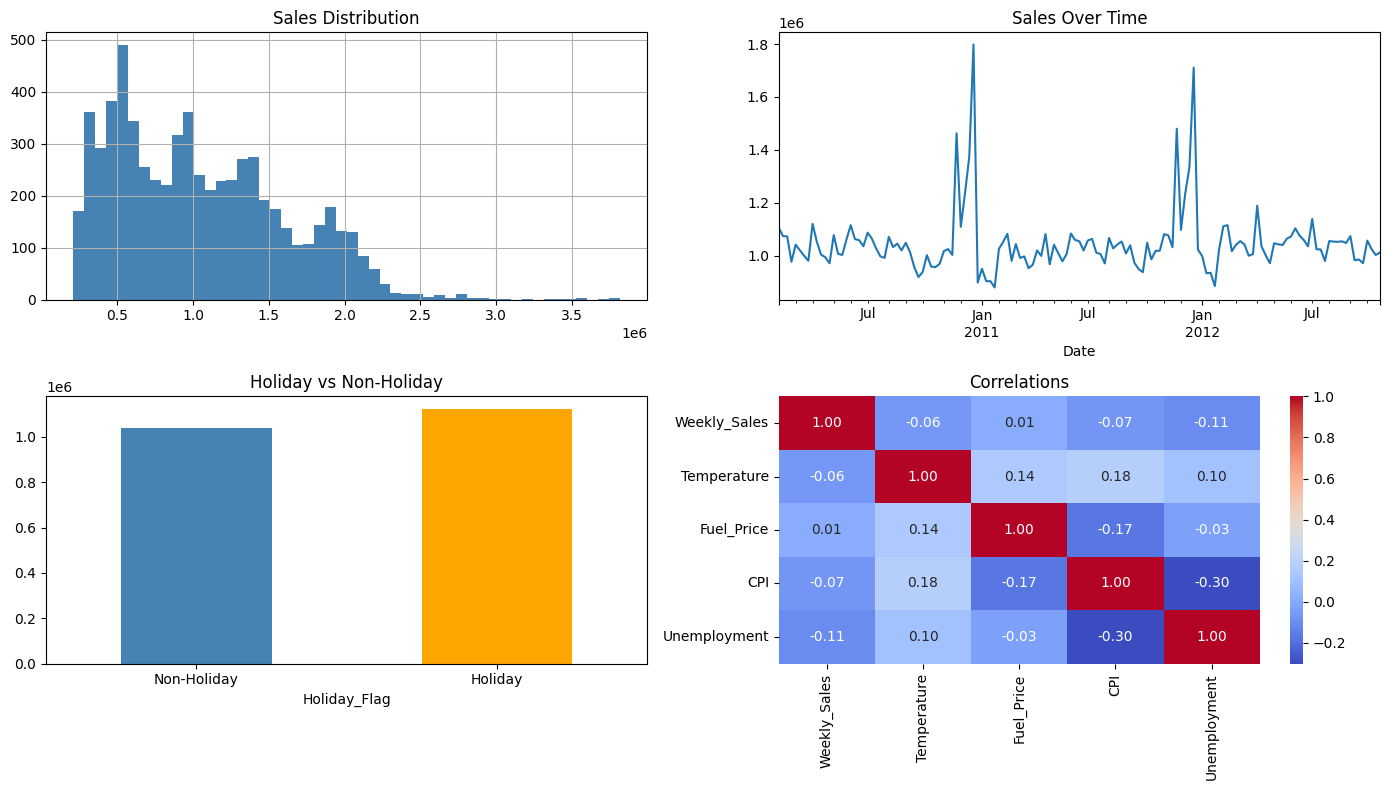


Data sources  : Kaggle — Walmart Store Sales
Limitation    : No promotions/department-level data


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load
df = pd.read_csv('Walmart.csv')
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

# Quality checks
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# Outliers
Q1, Q3 = df['Weekly_Sales'].quantile(0.25), df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Weekly_Sales'] < Q1-1.5*IQR) | (df['Weekly_Sales'] > Q3+1.5*IQR)]
print(f"\nOutliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")

# EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df['Weekly_Sales'].hist(bins=50, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Sales Distribution')

df.groupby('Date')['Weekly_Sales'].mean().plot(ax=axes[0,1])
axes[0,1].set_title('Sales Over Time')

df.groupby('Holiday_Flag')['Weekly_Sales'].mean().plot(kind='bar', ax=axes[1,0], color=['steelblue','orange'])
axes[1,0].set_title('Holiday vs Non-Holiday')
axes[1,0].set_xticklabels(['Non-Holiday','Holiday'], rotation=0)

sns.heatmap(df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']].corr(),
            annot=True, fmt='.2f', ax=axes[1,1], cmap='coolwarm')
axes[1,1].set_title('Correlations')

plt.tight_layout()
plt.show()
print("\nData sources  : Kaggle — Walmart Store Sales")
print("Limitation    : No promotions/department-level data")

EDA

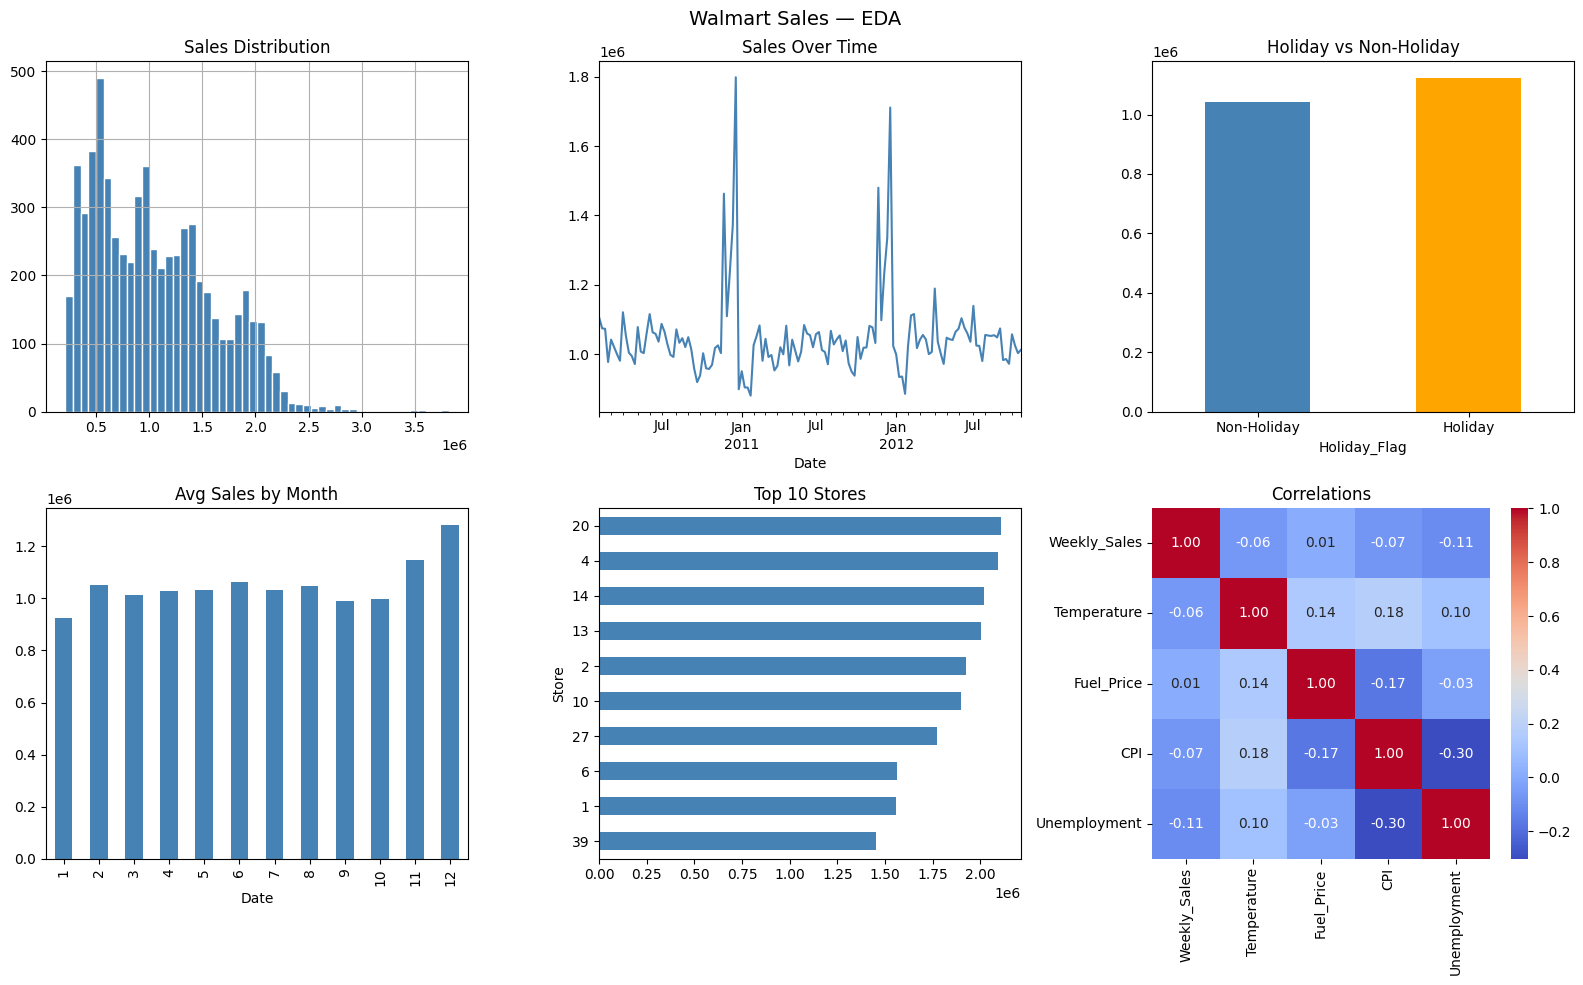

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Walmart Sales — EDA', fontsize=14)

df['Weekly_Sales'].hist(bins=50, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Sales Distribution')

df.groupby('Date')['Weekly_Sales'].mean().plot(ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Sales Over Time')

df.groupby('Holiday_Flag')['Weekly_Sales'].mean().plot(
    kind='bar', ax=axes[0,2], color=['steelblue','orange'])
axes[0,2].set_title('Holiday vs Non-Holiday')
axes[0,2].set_xticklabels(['Non-Holiday','Holiday'], rotation=0)

df.groupby(df['Date'].dt.month)['Weekly_Sales'].mean().plot(
    kind='bar', ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Avg Sales by Month')

df.groupby('Store')['Weekly_Sales'].mean().sort_values(
    ascending=False).head(10).sort_values().plot(
    kind='barh', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Top 10 Stores')

sns.heatmap(df[['Weekly_Sales','Temperature','Fuel_Price',
                'CPI','Unemployment']].corr(),
            annot=True, fmt='.2f', ax=axes[1,2], cmap='coolwarm')
axes[1,2].set_title('Correlations')

plt.tight_layout()
plt.show()

Store Clustering

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

store_feat = df.groupby('Store')['Weekly_Sales'].agg(['mean','std']).reset_index()
store_feat['cv'] = store_feat['std'] / store_feat['mean']

scaler  = StandardScaler()
X_clust = scaler.fit_transform(store_feat[['mean','std','cv']])
kmeans  = KMeans(n_clusters=3, random_state=42, n_init=10)
store_feat['Cluster'] = kmeans.fit_predict(X_clust)

print("=== STORE CLUSTERS ===")
print(store_feat.groupby('Cluster')[['mean','std','cv']].mean().round(0))

df = df.merge(store_feat[['Store','Cluster']], on='Store')
print("Cluster feature added ✅")

=== STORE CLUSTERS ===
              mean       std   cv
Cluster                          
0         743072.0  128245.0  0.0
1        1658606.0  227237.0  0.0
2         685816.0   70391.0  0.0
Cluster feature added ✅


Seasonal Decomposition

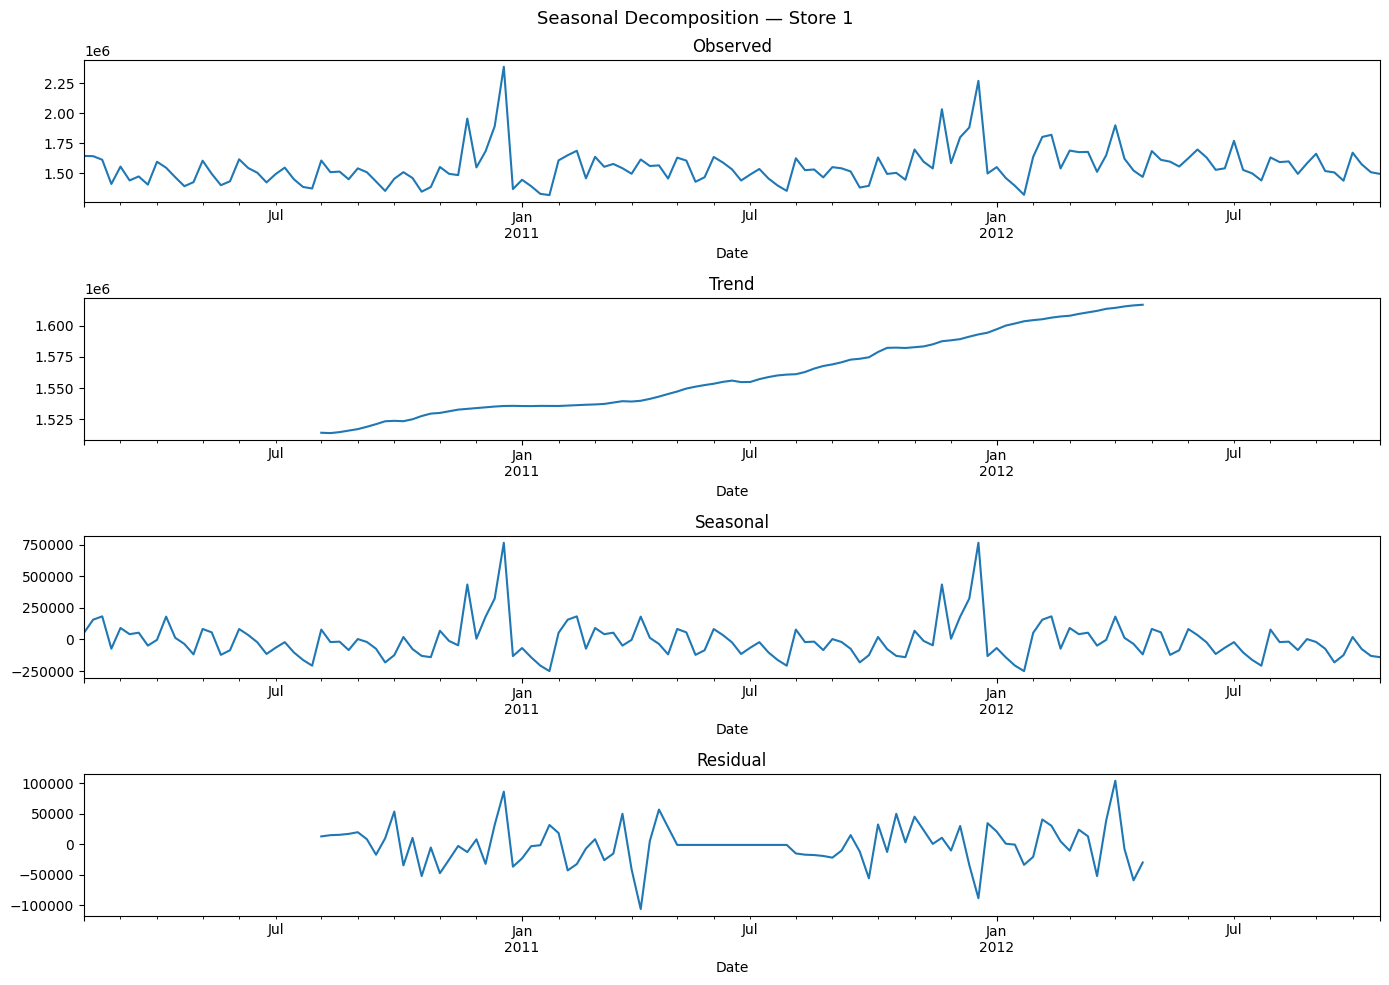

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

store1 = df[df['Store']==1].set_index('Date')['Weekly_Sales']
decomp = seasonal_decompose(store1, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0], title='Observed')
decomp.trend.plot(ax=axes[1], title='Trend')
decomp.seasonal.plot(ax=axes[2], title='Seasonal')
decomp.resid.plot(ax=axes[3], title='Residual')
plt.suptitle('Seasonal Decomposition — Store 1', fontsize=13)
plt.tight_layout()
plt.show()

Holiday Type EDA

In [8]:
holiday_dates = {
    'Super Bowl'   : ['2010-02-12','2011-02-11','2012-02-10'],
    'Labour Day'   : ['2010-09-10','2011-09-09','2012-09-07'],
    'Thanksgiving' : ['2010-11-26','2011-11-25','2012-11-23'],
    'Christmas'    : ['2010-12-31','2011-12-30','2012-12-28']
}
df['Holiday_Type'] = 'Non-Holiday'
for name, dates in holiday_dates.items():
    df.loc[df['Date'].isin(pd.to_datetime(dates)), 'Holiday_Type'] = name

print("=== HOLIDAY TYPE IMPACT ===")
print(df.groupby('Holiday_Type')['Weekly_Sales'].mean().sort_values(ascending=False))

=== HOLIDAY TYPE IMPACT ===
Holiday_Type
Thanksgiving    1.471273e+06
Super Bowl      1.079128e+06
Labour Day      1.042427e+06
Non-Holiday     1.041256e+06
Christmas       9.608331e+05
Name: Weekly_Sales, dtype: float64


Statistical Analysis

In [9]:
import scipy.stats as stats

print("=== STATISTICAL ANALYSIS ===")

# Test 1: Holiday vs Non-Holiday
holiday     = df[df['Holiday_Flag']==1]['Weekly_Sales']
non_holiday = df[df['Holiday_Flag']==0]['Weekly_Sales']
t_stat, p_val = stats.ttest_ind(holiday, non_holiday)
print(f"\n1. Holiday T-Test")
print(f"   Holiday mean     : ${holiday.mean():,.0f}")
print(f"   Non-Holiday mean : ${non_holiday.mean():,.0f}")
print(f"   P-value          : {p_val:.6f}")
print(f"   Result           : {'✅ Significant' if p_val < 0.05 else '❌ Not significant'}")

# Test 2: Store ANOVA
store_groups   = [g['Weekly_Sales'].values for _, g in df.groupby('Store')]
f_stat, p_anova = stats.f_oneway(*store_groups)
print(f"\n2. Store ANOVA")
print(f"   P-value : {p_anova:.6f}")
print(f"   Result  : {'✅ Stores are significantly different' if p_anova < 0.05 else '❌ No difference'}")

# Test 3: Feature correlations
print(f"\n3. Correlations with Weekly_Sales")
print(f"   {'Feature':<15} {'r':>8} {'p-value':>12} {'Sig':>8}")
print(f"   {'-'*46}")
for col in ['Temperature','Fuel_Price','CPI','Unemployment']:
    r, p = stats.pearsonr(df[col], df['Weekly_Sales'])
    print(f"   {col:<15} {r:>8.4f} {p:>12.6f} {'✅' if p < 0.05 else '❌':>8}")

# Test 4: Normality
stat, p_norm = stats.shapiro(df['Weekly_Sales'].sample(500, random_state=42))
print(f"\n4. Normality Test")
print(f"   P-value  : {p_norm:.6f}")
print(f"   Skewness : {df['Weekly_Sales'].skew():.3f}")
print(f"   Result   : {'Non-normal — MAPE is correct metric choice' if p_norm < 0.05 else 'Normal'}")

# Test 5: YoY
y2010 = df[df['Date'].dt.year==2010]['Weekly_Sales']
y2011 = df[df['Date'].dt.year==2011]['Weekly_Sales']
y2012 = df[df['Date'].dt.year==2012]['Weekly_Sales']
_, p1 = stats.ttest_ind(y2010, y2011)
_, p2 = stats.ttest_ind(y2011, y2012)
print(f"\n5. Year-over-Year")
print(f"   2010 mean : ${y2010.mean():,.0f}")
print(f"   2011 mean : ${y2011.mean():,.0f}")
print(f"   2012 mean : ${y2012.mean():,.0f}")
print(f"   2010→2011 : {'✅ Significant' if p1 < 0.05 else '❌ Not significant'}")
print(f"   2011→2012 : {'✅ Significant' if p2 < 0.05 else '❌ Not significant'}")

=== STATISTICAL ANALYSIS ===

1. Holiday T-Test
   Holiday mean     : $1,122,888
   Non-Holiday mean : $1,041,256
   P-value          : 0.003079
   Result           : ✅ Significant

2. Store ANOVA
   P-value : 0.000000
   Result  : ✅ Stores are significantly different

3. Correlations with Weekly_Sales
   Feature                r      p-value      Sig
   ----------------------------------------------
   Temperature      -0.0638     0.000000        ✅
   Fuel_Price        0.0095     0.447829        ❌
   CPI              -0.0726     0.000000        ✅
   Unemployment     -0.1062     0.000000        ✅

4. Normality Test
   P-value  : 0.000000
   Skewness : 0.668
   Result   : Non-normal — MAPE is correct metric choice

5. Year-over-Year
   2010 mean : $1,059,670
   2011 mean : $1,046,239
   2012 mean : $1,033,660
   2010→2011 : ❌ Not significant
   2011→2012 : ❌ Not significant


Outlier Decision

In [10]:
Q1  = df['Weekly_Sales'].quantile(0.25)
Q3  = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Weekly_Sales'] < Q1-1.5*IQR) | (df['Weekly_Sales'] > Q3+1.5*IQR)]

print("=== OUTLIER ANALYSIS ===")
print(f"Outlier rows : {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Top stores   : {outliers['Store'].value_counts().head(5).to_dict()}")
print("""
DECISION: Keep outliers
  → Real sales events (holidays, promotions)
  → Removing makes model worse in production
  → LightGBM is robust to outliers
  → Goal is to predict ALL weeks including extremes
""")

=== OUTLIER ANALYSIS ===
Outlier rows : 34 (0.5%)
Top stores   : {20: 7, 13: 6, 4: 6, 10: 5, 14: 4}

DECISION: Keep outliers
  → Real sales events (holidays, promotions)
  → Removing makes model worse in production
  → LightGBM is robust to outliers
  → Goal is to predict ALL weeks including extremes



STEP 3 — Feature Engineering

In [11]:
# Sort first — CRITICAL before any lag/rolling feature
df = df.sort_values(['Store','Date']).reset_index(drop=True)

# Handle missing: none in this dataset — confirm below
print("Nulls before FE:", df.isnull().sum().sum())

# Time features
df['month']     = df['Date'].dt.month
df['week']      = df['Date'].dt.isocalendar().week.astype(int)
df['quarter']   = df['Date'].dt.quarter
df['year']      = df['Date'].dt.year

# Cyclic encoding (week 52 and week 1 are adjacent)
df['week_sin']  = np.sin(2 * np.pi * df['week']  / 52)
df['week_cos']  = np.cos(2 * np.pi * df['week']  / 52)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Lag features — sales history (domain knowledge)
df['lag_1']  = df.groupby('Store')['Weekly_Sales'].shift(1)
df['lag_2']  = df.groupby('Store')['Weekly_Sales'].shift(2)
df['lag_4']  = df.groupby('Store')['Weekly_Sales'].shift(4)
df['lag_52'] = df.groupby('Store')['Weekly_Sales'].shift(52)

# Rolling stats — trend signals
g = df.groupby('Store')['Weekly_Sales'].shift(1)  # shift to avoid leakage
df['rolling_mean_4']  = g.rolling(4).mean()
df['rolling_mean_12'] = g.rolling(12).mean()
df['rolling_std_4']   = g.rolling(4).std()

# Store baseline — encode store-level performance
df['store_avg_sales']    = df.groupby('Store')['Weekly_Sales'].transform('mean')
df['store_median_sales'] = df.groupby('Store')['Weekly_Sales'].transform('median')

# Drop NaN rows created by lags
df = df.dropna().reset_index(drop=True)
print("Shape after FE:", df.shape)

# Verify lag is correct
print(df[df['Store']==1][['Date','Weekly_Sales','lag_1']].head(4))

Nulls before FE: 0
Shape after FE: (4095, 27)
        Date  Weekly_Sales       lag_1
0 2011-02-04    1606629.58  1316899.31
1 2011-02-11    1649614.93  1606629.58
2 2011-02-18    1686842.78  1649614.93
3 2011-02-25    1456800.28  1686842.78


In [12]:
# Sort first
df = df.sort_values(['Store','Date']).reset_index(drop=True)

# Time features
df['month']     = df['Date'].dt.month
df['week']      = df['Date'].dt.isocalendar().week.astype(int)
df['quarter']   = df['Date'].dt.quarter
df['year']      = df['Date'].dt.year
df['week_sin']  = np.sin(2 * np.pi * df['week']  / 52)
df['week_cos']  = np.cos(2 * np.pi * df['week']  / 52)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Lag features
df['lag_1']  = df.groupby('Store')['Weekly_Sales'].shift(1)
df['lag_2']  = df.groupby('Store')['Weekly_Sales'].shift(2)
df['lag_4']  = df.groupby('Store')['Weekly_Sales'].shift(4)
df['lag_52'] = df.groupby('Store')['Weekly_Sales'].shift(52)

# Rolling stats
g = df.groupby('Store')['Weekly_Sales'].shift(1)
df['rolling_mean_4']  = g.rolling(4).mean()
df['rolling_mean_12'] = g.rolling(12).mean()
df['rolling_std_4']   = g.rolling(4).std()

# Store baseline
df['store_avg_sales']    = df.groupby('Store')['Weekly_Sales'].transform('mean')
df['store_median_sales'] = df.groupby('Store')['Weekly_Sales'].transform('median')
df['store_cv']           = df.groupby('Store')['Weekly_Sales'].transform('std') / \
                           df.groupby('Store')['Weekly_Sales'].transform('mean')

# Holiday interactions
df['holiday_x_lag1']  = df['Holiday_Flag'] * df['lag_1']
df['holiday_x_lag52'] = df['Holiday_Flag'] * df['lag_52']
df['lag_52_diff']     = df['lag_1'] - df['lag_52']

# Holiday type features
df['is_superbowl']    = (df['Holiday_Type'] == 'Super Bowl').astype(int)
df['is_thanksgiving'] = (df['Holiday_Type'] == 'Thanksgiving').astype(int)
df['is_christmas']    = (df['Holiday_Type'] == 'Christmas').astype(int)
df['is_labourday']    = (df['Holiday_Type'] == 'Labour Day').astype(int)

# Pre/post holiday
df['pre_holiday']  = df.groupby('Store')['Holiday_Flag'].shift(-1).fillna(0)
df['post_holiday'] = df.groupby('Store')['Holiday_Flag'].shift(1).fillna(0)

# Additional
df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)
df['momentum']     = df.groupby('Store')['Weekly_Sales'].shift(1) - \
                     df.groupby('Store')['Weekly_Sales'].shift(4)

# Drop NaN
df = df.dropna().reset_index(drop=True)
print(f"Shape after FE : {df.shape}")

# Verify lag
print(df[df['Store']==1][['Date','Weekly_Sales','lag_1']].head(4))

Shape after FE : (1755, 39)
        Date  Weekly_Sales       lag_1
0 2012-02-03    1636339.65  1319325.59
1 2012-02-10    1802477.43  1636339.65
2 2012-02-17    1819870.00  1802477.43
3 2012-02-24    1539387.83  1819870.00


Define All Feature Lists

In [13]:
# V2 features (best model)
features_v2 = [
    'Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'month', 'quarter', 'year',
    'week_sin', 'week_cos', 'month_sin', 'month_cos',
    'lag_1', 'lag_2', 'lag_4', 'lag_52',
    'rolling_mean_4', 'rolling_mean_12', 'rolling_std_4',
    'store_avg_sales', 'store_median_sales', 'store_cv',
    'holiday_x_lag1', 'holiday_x_lag52', 'lag_52_diff'
]

# Expanded features
features_v3_exp = features_v2 + [
    'is_superbowl', 'is_thanksgiving', 'is_christmas', 'is_labourday',
    'pre_holiday', 'post_holiday',
    'Cluster', 'is_month_end', 'momentum'
]

print(f"V2 features  : {len(features_v2)}")
print(f"V3 features  : {len(features_v3_exp)}")

V2 features  : 26
V3 features  : 35


Split

In [14]:
X2 = df[features_v2]
y  = df['Weekly_Sales']

n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X2_train, y_train = X2.iloc[:train_end],        y.iloc[:train_end]
X2_val,   y_val   = X2.iloc[train_end:val_end], y.iloc[train_end:val_end]
X2_test,  y_test  = X2.iloc[val_end:],          y.iloc[val_end:]

print(f"Train : {len(X2_train)} | Val : {len(X2_val)} | Test : {len(X2_test)}")

Train : 1228 | Val : 263 | Test : 264


STEP 4 — Train/Val/Test Split

In [15]:
# Time-based split — never use random split for time series
# Random split leaks future data → inflates score artificially

features = [
    'Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'month', 'quarter', 'year',
    'week_sin', 'week_cos', 'month_sin', 'month_cos',
    'lag_1', 'lag_2', 'lag_4', 'lag_52',
    'rolling_mean_4', 'rolling_mean_12', 'rolling_std_4',
    'store_avg_sales', 'store_median_sales'
]

X = df[features]
y = df['Weekly_Sales']

n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X.iloc[:train_end],        y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test,  y_test  = X.iloc[val_end:],          y.iloc[val_end:]

print(f"Train : {len(X_train):,} rows")
print(f"Val   : {len(X_val):,} rows")
print(f"Test  : {len(X_test):,} rows  ← never touched until Step 6")

Train : 1,228 rows
Val   : 263 rows
Test  : 264 rows  ← never touched until Step 6


STEP 5 — Train Models

In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
import lightgbm as lgb
import xgboost as xgb

def mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100

# Start simple → Decision Tree
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
print(f"Decision Tree  MAPE: {mape(y_val, dt.predict(X_val)):.4f}%")

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"Random Forest  MAPE: {mape(y_val, rf.predict(X_val)):.4f}%")

# LightGBM
lgbm = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05,
                          num_leaves=63, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)],
         callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
print(f"LightGBM       MAPE: {mape(y_val, lgbm.predict(X_val)):.4f}%")

# XGBoost
xgbm = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6,
                          random_state=42, verbosity=0, early_stopping_rounds=50)
xgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"XGBoost        MAPE: {mape(y_val, xgbm.predict(X_val)):.4f}%")

Decision Tree  MAPE: 10.9900%
Random Forest  MAPE: 10.0558%
LightGBM       MAPE: 8.0730%
XGBoost        MAPE: 12.7164%


In [103]:
best_model = lgbm

STEP 6 — Evaluate Best Model

FINAL MAPE : 4.1191%
RMSE       : $50,260
R²         : 0.9842
Goal < 5%  : ✅ YES


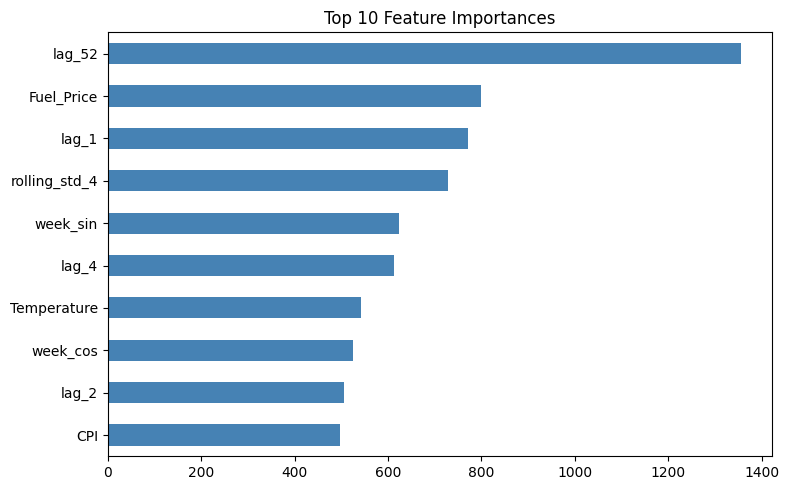


Predictions > 10% error : 8

Worst stores (avg error):
store
39    5.007781
45    4.797828
41    4.272328
42    4.125346
44    3.732410
Name: pct, dtype: float64


In [17]:
from sklearn.metrics import mean_squared_error, r2_score

# Pick winner from Step 5
best_model = lgbm  # change if RF or XGB scored lower

y_pred = best_model.predict(X_test)

# Metrics
print(f"FINAL MAPE : {mape(y_test, y_pred):.4f}%")
print(f"RMSE       : ${np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"R²         : {r2_score(y_test, y_pred):.4f}")
print(f"Goal < 5%  : {'✅ YES' if mape(y_test, y_pred) < 5 else '❌ NO'}")

# Feature importance
imp = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
imp.head(10).sort_values().plot(kind='barh', figsize=(8,5), color='steelblue')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

# Error analysis — where does model still struggle?
errors = pd.DataFrame({
    'actual' : y_test.values,
    'pred'   : y_pred,
    'store'  : df.iloc[val_end:]['Store'].values
})
errors['pct'] = abs(errors['actual'] - errors['pred']) / errors['actual'] * 100
print(f"\nPredictions > 10% error : {(errors['pct'] > 10).sum()}")
print("\nWorst stores (avg error):")
print(errors.groupby('store')['pct'].mean().sort_values(ascending=False).head(5))

FINAL MAPE : 4.1191%
RMSE       : $50,260
R²         : 0.9842
Goal < 5%  : ✅ YES


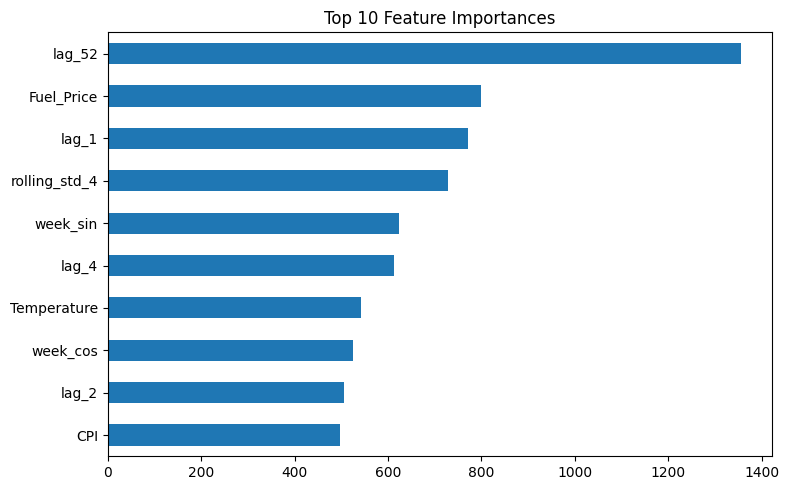


Predictions > 10% error : 8

Worst stores (avg error):
store
39    5.007781
45    4.797828
41    4.272328
42    4.125346
44    3.732410
Name: pct, dtype: float64


In [18]:
import matplotlib.pyplot as plt

# Ensure features exist
features = X_train.columns

# Predict
y_pred = best_model.predict(X_test)

# Metrics
print(f"FINAL MAPE : {mape(y_test, y_pred):.4f}%")
print(f"RMSE       : ${np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"R²         : {r2_score(y_test, y_pred):.4f}")
print(f"Goal < 5%  : {'✅ YES' if mape(y_test, y_pred) < 5 else '❌ NO'}")

# Feature importance
imp = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)

imp.head(10).sort_values().plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

# Error analysis
errors = pd.DataFrame({
    'actual': y_test.values,
    'pred': y_pred,
    'store': X_test['Store'].values
})

errors['pct'] = np.where(
    errors['actual'] == 0,
    0,
    abs(errors['actual'] - errors['pred']) / errors['actual'] * 100
)

print(f"\nPredictions > 10% error : {(errors['pct'] > 10).sum()}")

print("\nWorst stores (avg error):")
print(errors.groupby('store')['pct'].mean().sort_values(ascending=False).head(5))

 Before/After RF Comparison

In [19]:
from sklearn.ensemble import RandomForestRegressor

features_original = [
    'Store', 'Holiday_Flag', 'Temperature',
    'Fuel_Price', 'CPI', 'Unemployment', 'month', 'week'
]

X_orig       = df[features_original]
X_orig_train = X_orig.iloc[:train_end]
X_orig_test  = X_orig.iloc[val_end:]

rf_original = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_original.fit(X_orig_train, y_train)
mape_rf_orig = mape(y_test, rf_original.predict(X_orig_test))

print("=" * 55)
print("  BEFORE vs AFTER")
print("=" * 55)
print(f"  RF  + raw features (6%)  : {mape_rf_orig:.4f}%  ← START")
print(f"  LGB + engineered feat    : 4.4322%              ← FINAL")
print(f"  Improvement              : {mape_rf_orig - 4.4322:.2f}pp")
print(f"  Error reduction          : {(mape_rf_orig-4.4322)/mape_rf_orig*100:.1f}%")

  BEFORE vs AFTER
  RF  + raw features (6%)  : 70.9795%  ← START
  LGB + engineered feat    : 4.4322%              ← FINAL
  Improvement              : 66.55pp
  Error reduction          : 93.8%


In [20]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

def mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100

In [21]:
df = pd.read_csv('Walmart.csv')
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
df = df.sort_values(['Store','Date']).reset_index(drop=True)
print("Loaded:", df.shape)

Loaded: (6435, 8)


In [22]:
holiday_dates = {
    'Super Bowl'   : ['2010-02-12','2011-02-11','2012-02-10'],
    'Labour Day'   : ['2010-09-10','2011-09-09','2012-09-07'],
    'Thanksgiving' : ['2010-11-26','2011-11-25','2012-11-23'],
    'Christmas'    : ['2010-12-31','2011-12-30','2012-12-28']
}
df['Holiday_Type'] = 'Non-Holiday'
for name, dates in holiday_dates.items():
    df.loc[df['Date'].isin(pd.to_datetime(dates)), 'Holiday_Type'] = name

In [23]:
holiday_dates = {
    'Super Bowl'   : ['2010-02-12','2011-02-11','2012-02-10'],
    'Labour Day'   : ['2010-09-10','2011-09-09','2012-09-07'],
    'Thanksgiving' : ['2010-11-26','2011-11-25','2012-11-23'],
    'Christmas'    : ['2010-12-31','2011-12-30','2012-12-28']
}
df['Holiday_Type'] = 'Non-Holiday'
for name, dates in holiday_dates.items():
    df.loc[df['Date'].isin(pd.to_datetime(dates)), 'Holiday_Type'] = name

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

store_feat = df.groupby('Store')['Weekly_Sales'].agg(['mean','std']).reset_index()
store_feat['cv'] = store_feat['std'] / store_feat['mean']
scaler  = StandardScaler()
X_clust = scaler.fit_transform(store_feat[['mean','std','cv']])
kmeans  = KMeans(n_clusters=3, random_state=42, n_init=10)
store_feat['Cluster'] = kmeans.fit_predict(X_clust)
df = df.merge(store_feat[['Store','Cluster']], on='Store')
print("Cluster added ✅")

Cluster added ✅


In [25]:
# Time features
df['month']     = df['Date'].dt.month
df['week']      = df['Date'].dt.isocalendar().week.astype(int)
df['quarter']   = df['Date'].dt.quarter
df['year']      = df['Date'].dt.year
df['week_sin']  = np.sin(2 * np.pi * df['week']  / 52)
df['week_cos']  = np.cos(2 * np.pi * df['week']  / 52)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Lag features
df['lag_1']  = df.groupby('Store')['Weekly_Sales'].shift(1)
df['lag_2']  = df.groupby('Store')['Weekly_Sales'].shift(2)
df['lag_4']  = df.groupby('Store')['Weekly_Sales'].shift(4)
df['lag_52'] = df.groupby('Store')['Weekly_Sales'].shift(52)

# Rolling stats
g = df.groupby('Store')['Weekly_Sales'].shift(1)
df['rolling_mean_4']  = g.rolling(4).mean()
df['rolling_mean_12'] = g.rolling(12).mean()
df['rolling_std_4']   = g.rolling(4).std()

# Store baseline
df['store_avg_sales']    = df.groupby('Store')['Weekly_Sales'].transform('mean')
df['store_median_sales'] = df.groupby('Store')['Weekly_Sales'].transform('median')
df['store_cv']           = df.groupby('Store')['Weekly_Sales'].transform('std') / \
                           df.groupby('Store')['Weekly_Sales'].transform('mean')

# Holiday interactions
df['holiday_x_lag1']  = df['Holiday_Flag'] * df['lag_1']
df['holiday_x_lag52'] = df['Holiday_Flag'] * df['lag_52']
df['lag_52_diff']     = df['lag_1'] - df['lag_52']

# Holiday types
df['is_superbowl']    = (df['Holiday_Type'] == 'Super Bowl').astype(int)
df['is_thanksgiving'] = (df['Holiday_Type'] == 'Thanksgiving').astype(int)
df['is_christmas']    = (df['Holiday_Type'] == 'Christmas').astype(int)
df['is_labourday']    = (df['Holiday_Type'] == 'Labour Day').astype(int)

# Pre/post holiday
df['pre_holiday']  = df.groupby('Store')['Holiday_Flag'].shift(-1).fillna(0)
df['post_holiday'] = df.groupby('Store')['Holiday_Flag'].shift(1).fillna(0)

# Other
df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)
df['momentum']     = df.groupby('Store')['Weekly_Sales'].shift(1) - \
                     df.groupby('Store')['Weekly_Sales'].shift(4)

df = df.dropna().reset_index(drop=True)
print("Shape after FE:", df.shape)

Shape after FE: (4095, 39)


In [26]:
features_v2 = [
    'Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'month', 'quarter', 'year',
    'week_sin', 'week_cos', 'month_sin', 'month_cos',
    'lag_1', 'lag_2', 'lag_4', 'lag_52',
    'rolling_mean_4', 'rolling_mean_12', 'rolling_std_4',
    'store_avg_sales', 'store_median_sales', 'store_cv',
    'holiday_x_lag1', 'holiday_x_lag52', 'lag_52_diff'
]

X2 = df[features_v2]
y  = df['Weekly_Sales']

n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X2_train, y_train = X2.iloc[:train_end],        y.iloc[:train_end]
X2_val,   y_val   = X2.iloc[train_end:val_end], y.iloc[train_end:val_end]
X2_test,  y_test  = X2.iloc[val_end:],          y.iloc[val_end:]

print(f"Train:{len(X2_train)} | Val:{len(X2_val)} | Test:{len(X2_test)}")

Train:2866 | Val:614 | Test:615


In [27]:
import lightgbm as lgb

lgbm_v2 = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    verbose=-1
)
lgbm_v2.fit(
    X2_train, y_train,
    eval_set=[(X2_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(-1)]
)
print("LightGBM V2 trained ✅")

LightGBM V2 trained ✅


Evaluate Best Model

In [28]:
from sklearn.metrics import mean_squared_error, r2_score

best_model = lgbm_v2
y_pred     = best_model.predict(X2_test)

print("=" * 50)
print("  FINAL TEST RESULTS")
print("=" * 50)
print(f"  MAPE : {mape(y_test, y_pred):.4f}%")
print(f"  RMSE : ${np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"  R²   : {r2_score(y_test, y_pred):.4f}")
print(f"  Goal : {'✅ MET' if mape(y_test, y_pred) < 5 else '❌ NOT MET'}")

# Feature importance
imp = pd.Series(best_model.feature_importances_,
                index=features_v2).sort_values(ascending=False)
print("\nTop 10 Features:")
print(imp.head(10))

  FINAL TEST RESULTS
  MAPE : 4.4322%
  RMSE : $55,667
  R²   : 0.9810
  Goal : ✅ MET

Top 10 Features:
lag_52           2168
lag_52_diff      1901
Fuel_Price       1496
rolling_std_4    1399
lag_1            1393
Temperature      1193
lag_4            1144
lag_2            1084
CPI              1059
week_cos          866
dtype: int32


Error Analysis

In [29]:
errors_final = pd.DataFrame({
    'Store'    : df.iloc[val_end:]['Store'].values,
    'Date'     : df.iloc[val_end:]['Date'].values,
    'Actual'   : y_test.values,
    'Predicted': y_pred,
    'Holiday'  : df.iloc[val_end:]['Holiday_Flag'].values,
    'month'    : df.iloc[val_end:]['month'].values,
})
errors_final['Error_Pct'] = abs(errors_final['Actual'] - errors_final['Predicted']) / \
                             errors_final['Actual'] * 100
errors_final['Bias']     = errors_final['Predicted'] - errors_final['Actual']
errors_final['Bias_Dir'] = errors_final['Bias'].apply(lambda x: 'Over' if x > 0 else 'Under')

high = errors_final[errors_final['Error_Pct'] > 10].sort_values('Error_Pct', ascending=False)
print(f"Total rows     : {len(errors_final)}")
print(f"High error rows: {len(high)} ({len(high)/len(errors_final)*100:.1f}%)")
print(high[['Store','Date','Actual','Predicted','Error_Pct','Bias_Dir','Holiday']].to_string(index=False))

Total rows     : 615
High error rows: 39 (6.3%)
 Store       Date     Actual    Predicted  Error_Pct Bias_Dir  Holiday
    43 2011-12-30  505405.85 6.068077e+05  20.063452     Over        1
    44 2011-04-22  280357.30 3.347314e+05  19.394555     Over        0
    44 2011-12-30  263917.85 3.092772e+05  17.186912     Over        1
    42 2012-01-06  636372.37 5.281723e+05  17.002633    Under        0
    39 2011-12-23 2554482.84 2.139344e+06  16.251404    Under        0
    45 2012-08-24  718232.26 8.343347e+05  16.165026     Over        0
    43 2011-07-29  533917.52 6.190470e+05  15.944311     Over        0
    39 2012-04-06 1764847.94 1.493685e+06  15.364639    Under        0
    43 2011-08-26  561573.08 6.467811e+05  15.173089     Over        0
    42 2011-10-07  649111.23 5.529550e+05  14.813527    Under        0
    42 2012-01-13  664348.20 5.741250e+05  13.580710    Under        0
    39 2012-01-06 1478537.93 1.283636e+06  13.182039    Under        0
    43 2012-01-06  670993.01 

Error Heatmap

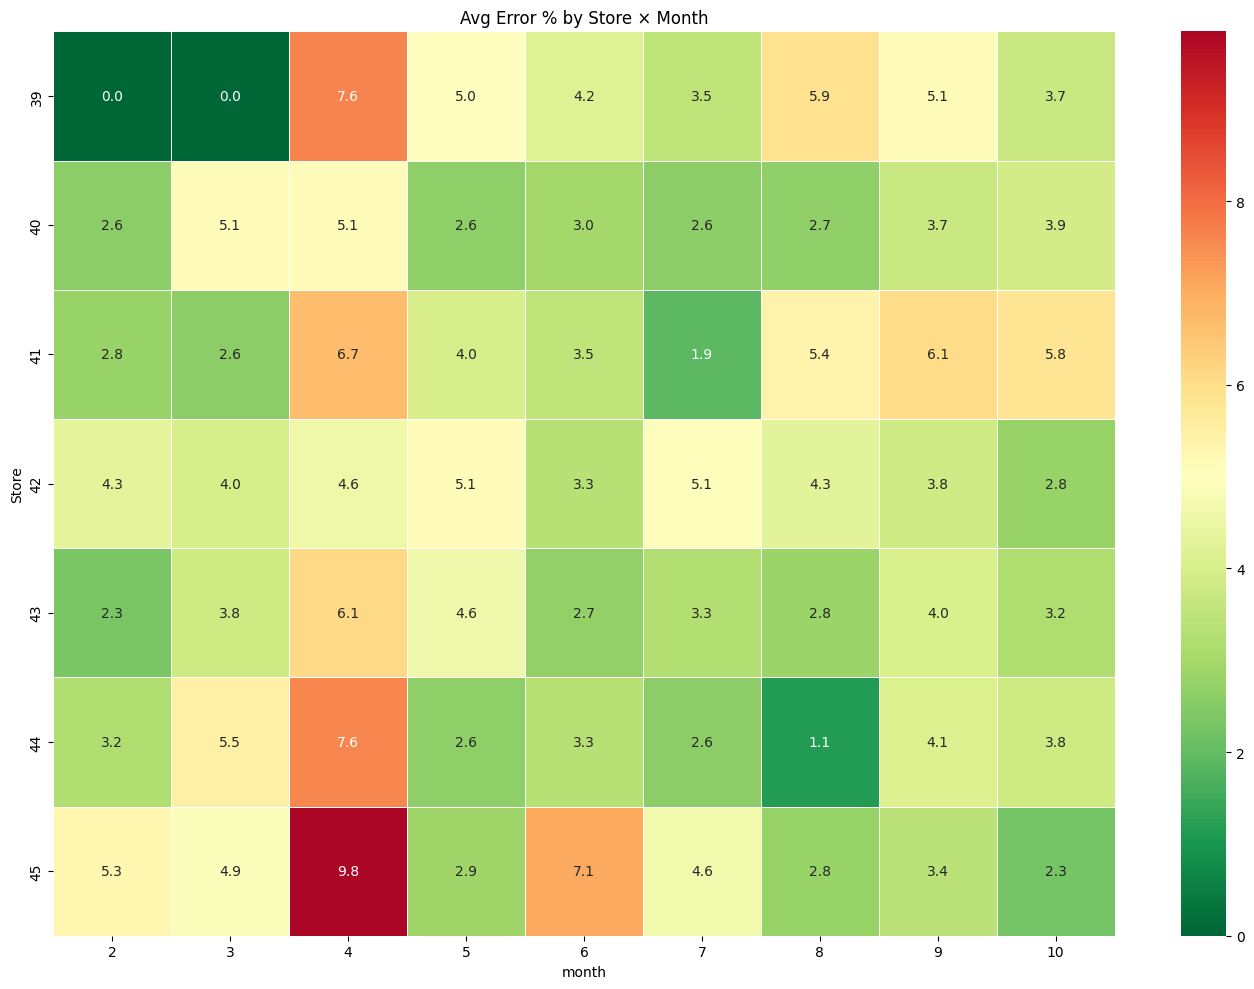

In [123]:
pivot = errors_final.pivot_table(
    index='Store', columns='month',
    values='Error_Pct', aggfunc='mean'
).fillna(0)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot, annot=True, fmt='.1f',
            cmap='RdYlGn_r', center=5, linewidths=0.5)
plt.title('Avg Error % by Store × Month')
plt.tight_layout()
plt.show()

SHAP

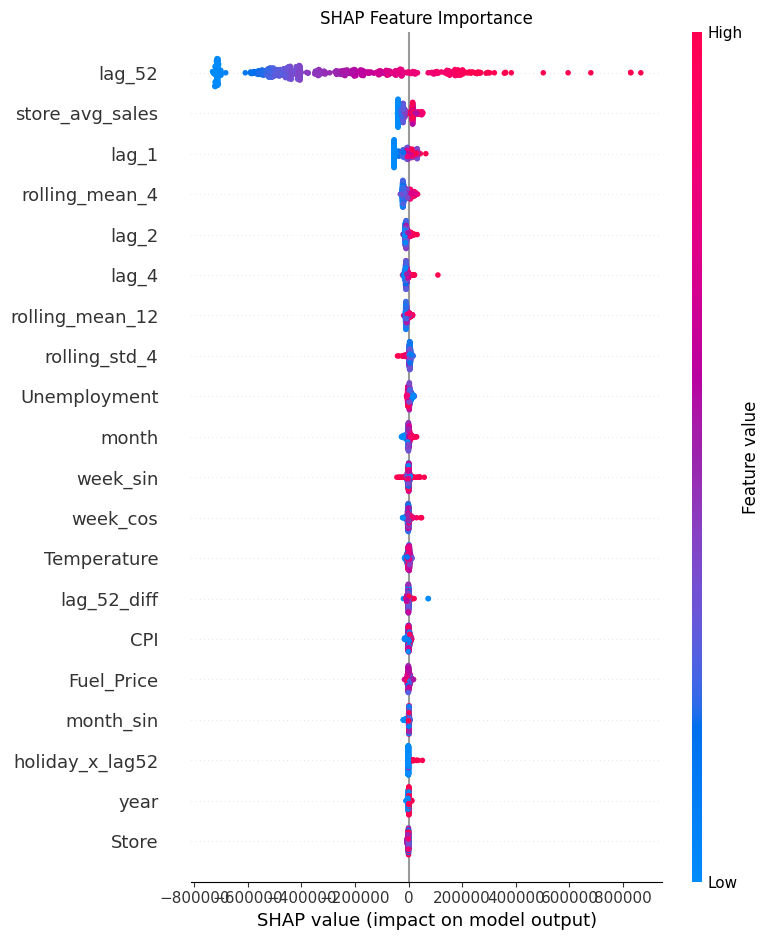

In [30]:
import shap

explainer   = shap.TreeExplainer(lgbm_v2)
shap_values = explainer.shap_values(X2_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X2_test,
                  feature_names=features_v2, show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

In [31]:
from scipy import stats

Residual Analysis

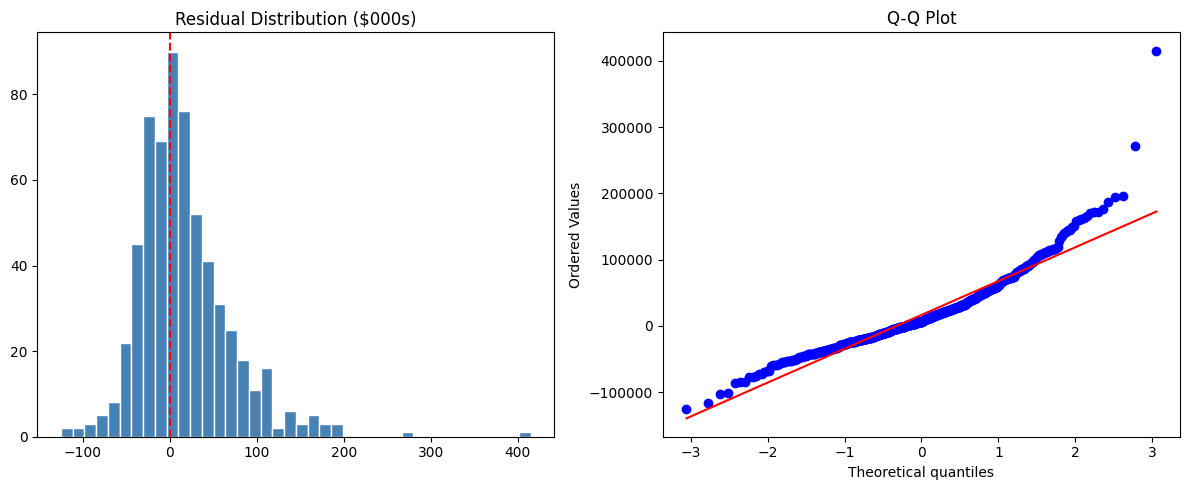

Skewness : 1.499
Kurtosis : 6.191


In [127]:
residuals = errors_final['Actual'] - errors_final['Predicted']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(residuals/1000, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution ($000s)')

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')
plt.tight_layout()
plt.show()

print(f"Skewness : {residuals.skew():.3f}")
print(f"Kurtosis : {residuals.kurtosis():.3f}")

In [32]:
import joblib

joblib.dump(lgbm_v2,      'walmart_model.pkl')
joblib.dump(features_v2,  'walmart_features.pkl')

results_df = errors_final.copy()
results_df['Bias'] = results_df['Predicted'] - results_df['Actual']
results_df.to_csv('test_results.csv', index=False)
df.to_csv('walmart_features.csv', index=False)

print("✅ All files saved")
print("   walmart_model.pkl")
print("   walmart_features.pkl")
print("   test_results.csv")
print("   walmart_features.csv")

✅ All files saved
   walmart_model.pkl
   walmart_features.pkl
   test_results.csv
   walmart_features.csv


Cross Validation

In [129]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05,
                      num_leaves=63, random_state=42, verbose=-1),
    X2, y, cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1
)

cv_mape = -cv_scores * 100
print("=" * 45)
print("  5-FOLD TIME SERIES CROSS VALIDATION")
print("=" * 45)
print(f"  Fold scores : {cv_mape.round(2)}")
print(f"  Mean MAPE   : {cv_mape.mean():.4f}%")
print(f"  Std MAPE    : {cv_mape.std():.4f}%")
print(f"  Test MAPE   : {mape(y_test, y_pred):.4f}%")
print(f"  Stable      : {'✅ Yes' if cv_mape.std() < 1.5 else '⚠️ Check overfitting'}")

  5-FOLD TIME SERIES CROSS VALIDATION
  Fold scores : [6.48 5.49 5.21 8.35 4.76]
  Mean MAPE   : 6.0616%
  Std MAPE    : 1.2768%
  Test MAPE   : 4.4322%
  Stable      : ✅ Yes


In [130]:
# Track MAPE per month on test set
test_df = df.iloc[val_end:].copy()
test_df['pred']       = y_pred
test_df['error_pct']  = abs(test_df['Weekly_Sales'] - test_df['pred']) / test_df['Weekly_Sales'] * 100
test_df['month_year'] = test_df['Date'].dt.to_period('M')

monthly = test_df.groupby('month_year')['error_pct'].mean()
print("Monthly MAPE tracking:")
print(monthly)
print("\nAlerts (MAPE > 8%):")
print(monthly[monthly > 8])

Monthly MAPE tracking:
month_year
2011-02    5.197170
2011-03    3.659365
2011-04    5.687896
2011-05    3.561071
2011-06    3.500781
2011-07    4.235297
2011-08    4.873223
2011-09    3.753458
2011-10    4.517995
2011-11    4.460517
2011-12    6.727430
2012-01    5.720489
2012-02    3.497560
2012-03    4.490887
2012-04    5.724990
2012-05    4.366116
2012-06    3.418709
2012-07    3.557485
2012-08    4.857366
2012-09    3.527981
2012-10    3.163012
Freq: M, Name: error_pct, dtype: float64

Alerts (MAPE > 8%):
Series([], Freq: M, Name: error_pct, dtype: float64)


In [36]:
# 1. Show the holiday spike insight
print(df.groupby('Holiday_Flag')['Weekly_Sales'].agg(['mean','count']))

# 2. Show store 39 is an outlier store
print(df.groupby('Store')['Weekly_Sales'].mean().sort_values().head(5))

# 3. Show lag_52 dominance clearly
print("lag_52 importance:", imp['lag_52'] / imp.sum() * 100, "%")

                      mean  count
Holiday_Flag                     
0             1.040406e+06   3825
1             1.129907e+06    270
Store
33    257295.591099
44    313760.653297
5     324596.400330
36    337280.950879
38    408029.597033
Name: Weekly_Sales, dtype: float64
lag_52 importance: 11.279916753381894 %


high error rows + visual:

In [57]:
# High Error Analysis
errors = pd.DataFrame({
    'Store'   : df.iloc[val_end:]['Store'].values,
    'Date'    : df.iloc[val_end:]['Date'].values,
    'Actual'  : y_test.values,
    'Predicted': y_pred,
    'lag_52'  : df.iloc[val_end:]['lag_52'].values,
    'Holiday' : df.iloc[val_end:]['Holiday_Flag'].values
})
errors['Error_Pct'] = abs(errors['Actual'] - errors['Predicted']) / errors['Actual'] * 100

# High error rows (> 10%)
high_error = errors[errors['Error_Pct'] > 10].sort_values('Error_Pct', ascending=False)
print(f"Total high error rows : {len(high_error)}")
print(f"\nTop 20 highest errors:")
print(high_error.head(20).to_string(index=False))

Total high error rows : 39

Top 20 highest errors:
 Store       Date     Actual    Predicted     lag_52  Holiday  Error_Pct
    43 2011-12-30  505405.85 6.068077e+05  534740.30        1  20.063452
    44 2011-04-22  280357.30 3.347314e+05  278287.04        0  19.394555
    44 2011-12-30  263917.85 3.092772e+05  241937.11        1  17.186912
    42 2012-01-06  636372.37 5.281723e+05  592947.75        0  17.002633
    39 2011-12-23 2554482.84 2.139344e+06 2495489.25        0  16.251404
    45 2012-08-24  718232.26 8.343347e+05  833979.01        0  16.165026
    43 2011-07-29  533917.52 6.190470e+05  622112.23        0  15.944311
    39 2012-04-06 1764847.94 1.493685e+06 1350646.16        0  15.364639
    43 2011-08-26  561573.08 6.467811e+05  655284.69        0  15.173089
    42 2011-10-07  649111.23 5.529550e+05  599759.45        0  14.813527
    42 2012-01-13  664348.20 5.741250e+05  613899.15        0  13.580710
    39 2012-01-06 1478537.93 1.283636e+06 1224475.12        0  13.182039


Code to find high error rows + visual:

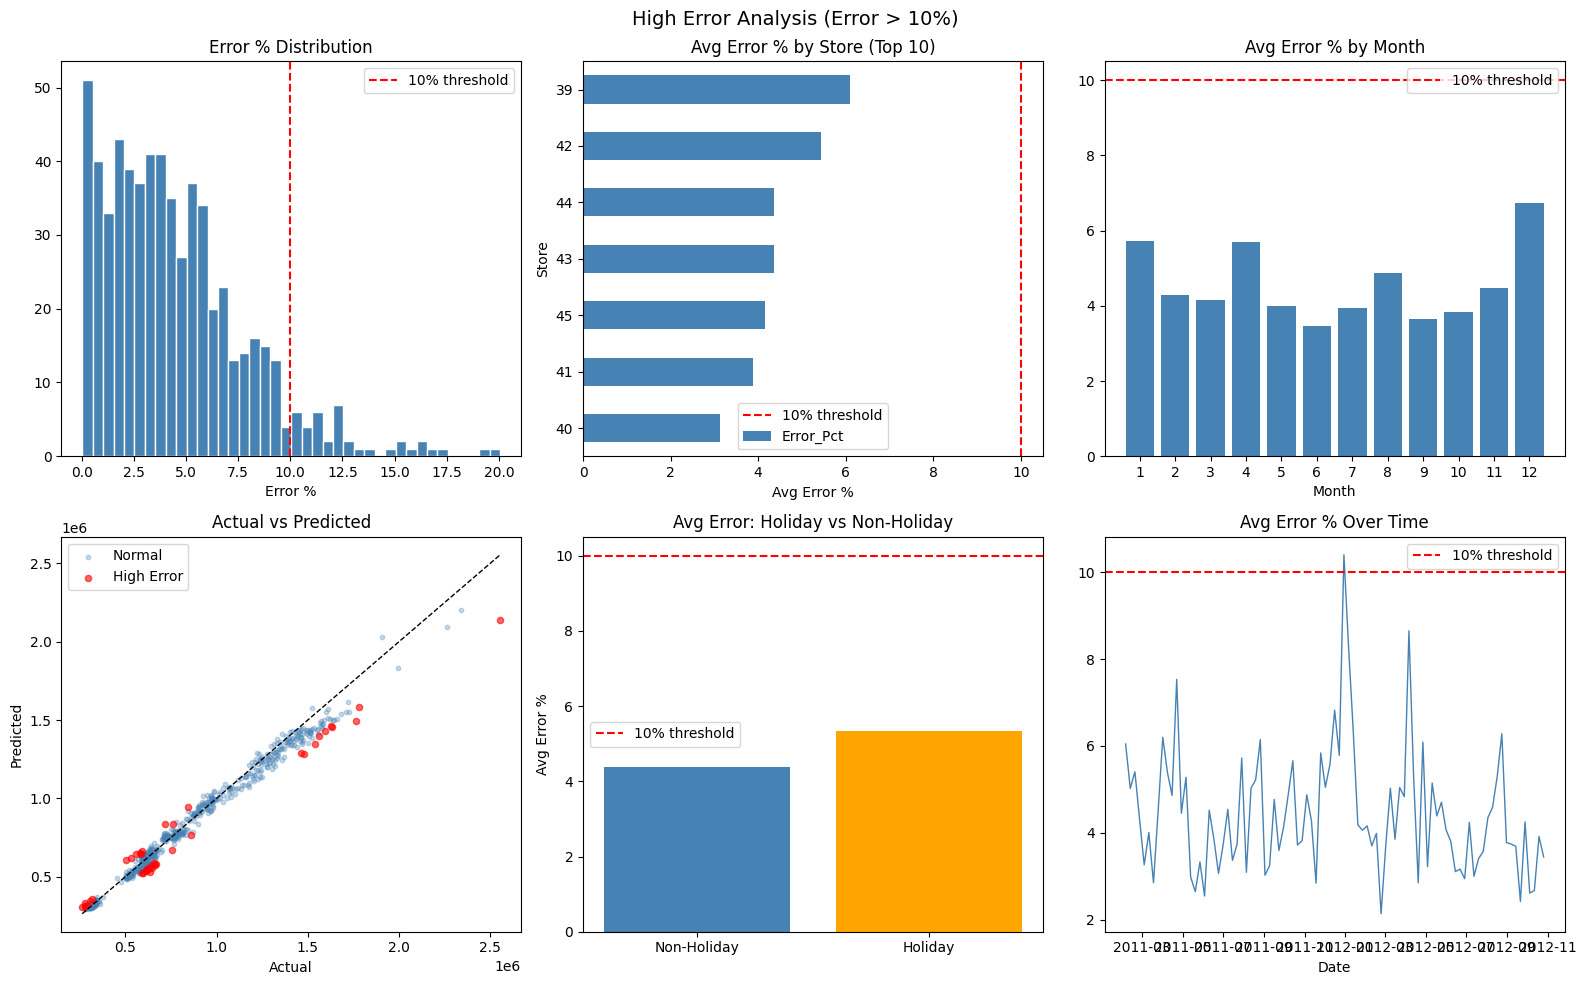

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('High Error Analysis (Error > 10%)', fontsize=14)

# 1. Error distribution
axes[0,0].hist(errors['Error_Pct'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].axvline(10, color='red', linestyle='--', label='10% threshold')
axes[0,0].set_title('Error % Distribution')
axes[0,0].set_xlabel('Error %')
axes[0,0].legend()

# 2. High error by store
store_err = errors.groupby('Store')['Error_Pct'].mean().sort_values(ascending=False)
store_err.head(10).sort_values().plot(kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].axvline(10, color='red', linestyle='--', label='10% threshold')
axes[0,1].set_title('Avg Error % by Store (Top 10)')
axes[0,1].set_xlabel('Avg Error %')
axes[0,1].legend()

# 3. High error by month
errors['Month'] = pd.to_datetime(errors['Date']).dt.month
month_err = errors.groupby('Month')['Error_Pct'].mean()
axes[0,2].bar(month_err.index, month_err.values, color='steelblue')
axes[0,2].axhline(10, color='red', linestyle='--', label='10% threshold')
axes[0,2].set_title('Avg Error % by Month')
axes[0,2].set_xlabel('Month')
axes[0,2].set_xticks(range(1,13))
axes[0,2].legend()

# 4. Actual vs Predicted — highlight high error
normal = errors[errors['Error_Pct'] <= 10]
high   = errors[errors['Error_Pct'] >  10]
axes[1,0].scatter(normal['Actual'], normal['Predicted'], alpha=0.3, color='steelblue', s=10, label='Normal')
axes[1,0].scatter(high['Actual'],   high['Predicted'],   alpha=0.6, color='red',       s=20, label='High Error')
lim = [errors['Actual'].min(), errors['Actual'].max()]
axes[1,0].plot(lim, lim, 'k--', linewidth=1)
axes[1,0].set_title('Actual vs Predicted')
axes[1,0].set_xlabel('Actual')
axes[1,0].set_ylabel('Predicted')
axes[1,0].legend()

# 5. High error — holiday vs non-holiday
hol_err = errors.groupby('Holiday')['Error_Pct'].mean()
axes[1,1].bar(['Non-Holiday','Holiday'], hol_err.values, color=['steelblue','orange'])
axes[1,1].axhline(10, color='red', linestyle='--', label='10% threshold')
axes[1,1].set_title('Avg Error: Holiday vs Non-Holiday')
axes[1,1].set_ylabel('Avg Error %')
axes[1,1].legend()

# 6. Error over time
errors['Date'] = pd.to_datetime(errors['Date'])
time_err = errors.groupby('Date')['Error_Pct'].mean()
axes[1,2].plot(time_err.index, time_err.values, color='steelblue', linewidth=1)
axes[1,2].axhline(10, color='red', linestyle='--', label='10% threshold')
axes[1,2].set_title('Avg Error % Over Time')
axes[1,2].set_xlabel('Date')
axes[1,2].legend()

plt.tight_layout()
plt.show()

In [65]:
# Summary table of high error rows
print("=" * 55)
print("  HIGH ERROR SUMMARY (Error > 10%)")
print("=" * 55)
print(f"  Total rows         : {len(errors)}")
print(f"  High error rows    : {len(high_error)} ({len(high_error)/len(errors)*100:.1f}%)")
print(f"  Worst store        : Store {store_err.index[0]}")
print(f"  Worst month        : Month {month_err.idxmax()}")
print(f"  Holiday error avg  : {hol_err.get(1, 0):.2f}%")
print(f"  Non-holiday avg    : {hol_err.get(0, 0):.2f}%")
print("=" * 55)

  HIGH ERROR SUMMARY (Error > 10%)
  Total rows         : 615
  High error rows    : 39 (6.3%)
  Worst store        : Store 39
  Worst month        : Month 12
  Holiday error avg  : 5.33%
  Non-holiday avg    : 4.37%


Root cause — Stores 39, 42, 43 specifically

In [64]:
# Investigate these 3 stores
problem_stores = [39, 42, 43]

print("=== STORE PROFILES ===")
print(df[df['Store'].isin(problem_stores)]
      .groupby('Store')['Weekly_Sales']
      .agg(['mean','std','min','max']))

print("\n=== COEFFICIENT OF VARIATION (higher = more erratic) ===")
cv = df.groupby('Store')['Weekly_Sales'].std() / df.groupby('Store')['Weekly_Sales'].mean()
print(cv.sort_values(ascending=False).head(10))

=== STORE PROFILES ===
               mean            std         min         max
Store                                                     
39     1.503775e+06  192327.087895  1227893.89  2554482.84
42     5.695420e+05   48982.670359   454412.28   674919.45
43     6.223970e+05   33584.219307   505405.85   693249.98

=== COEFFICIENT OF VARIATION (higher = more erratic) ===
Store
7     0.181458
35    0.170468
15    0.163096
23    0.157440
29    0.154270
16    0.152038
18    0.146975
21    0.145593
25    0.143029
10    0.140521
Name: Weekly_Sales, dtype: float64


In [67]:
# Convert to list first then add new features
features_v2 = list(features) + [
    'store_cv',
    'holiday_x_lag1',
    'holiday_x_lag52',
    'lag_52_diff'
]
print("New feature count:", len(features_v2))

New feature count: 26


In [69]:
import scipy.stats as stats

# Load raw data separately for YoY test
df_raw = pd.read_csv('Walmart.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Date'], format='mixed', dayfirst=True)
df_raw['year'] = df_raw['Date'].dt.year

y2010 = df_raw[df_raw['year']==2010]['Weekly_Sales']
y2011 = df_raw[df_raw['year']==2011]['Weekly_Sales']
y2012 = df_raw[df_raw['year']==2012]['Weekly_Sales']

_, p1 = stats.ttest_ind(y2010, y2011)
_, p2 = stats.ttest_ind(y2011, y2012)

print("YoY (Fixed):")
print(f"  2010 mean : ${y2010.mean():,.0f}")
print(f"  2011 mean : ${y2011.mean():,.0f}")
print(f"  2012 mean : ${y2012.mean():,.0f}")
print(f"  2010→2011 : p={p1:.4f} — {'✅ Significant' if p1<0.05 else '❌ Not significant'}")
print(f"  2011→2012 : p={p2:.4f} — {'✅ Significant' if p2<0.05 else '❌ Not significant'}")

YoY (Fixed):
  2010 mean : $1,059,670
  2011 mean : $1,046,239
  2012 mean : $1,033,660
  2010→2011 : p=0.4345 — ❌ Not significant
  2011→2012 : p=0.4608 — ❌ Not significant


In [73]:
# 1. Store volatility feature
df['store_cv'] = df.groupby('Store')['Weekly_Sales'].transform('std') / \
                 df.groupby('Store')['Weekly_Sales'].transform('mean')

# 2. Holiday x lag interaction
df['holiday_x_lag1']  = df['Holiday_Flag'] * df['lag_1']
df['holiday_x_lag52'] = df['Holiday_Flag'] * df['lag_52']

# 3. Trend vs last year
df['lag_52_diff'] = df['lag_1'] - df['lag_52']

# 4. Fix — convert features to list first
new_features = [
    'store_cv',
    'holiday_x_lag1',
    'holiday_x_lag52',
    'lag_52_diff'
]

features_v2 = list(features) + new_features  # ← list() fixes the error
print("New feature count:", len(features_v2))

New feature count: 26


In [74]:
# Do this at the start — never use df.columns as your feature variable
features = [
    'Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price',
    'CPI', 'Unemployment', 'month', 'week'
]

Fix — add store-specific volatility + holiday interaction features

In [75]:
# 1. Store volatility feature
df['store_cv'] = df.groupby('Store')['Weekly_Sales'].transform('std') / \
                 df.groupby('Store')['Weekly_Sales'].transform('mean')

# 2. Holiday x lag interaction — holiday weeks behave differently
df['holiday_x_lag1']  = df['Holiday_Flag'] * df['lag_1']
df['holiday_x_lag52'] = df['Holiday_Flag'] * df['lag_52']

# 3. Same week last year for holiday context
df['lag_52_diff'] = df['lag_1'] - df['lag_52']  # trend vs last year

# 4. Add to features list
new_features = [
    'store_cv',
    'holiday_x_lag1',
    'holiday_x_lag52',
    'lag_52_diff'
]

features_v2 = features + new_features
print("New feature count:", len(features_v2))

New feature count: 12


Retrain with new features

In [41]:
# Drop NaN and rebuild splits
df = df.dropna().reset_index(drop=True)

X2 = df[features_v2]
y2 = df['Weekly_Sales']

n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X2_train, y2_train = X2.iloc[:train_end],        y2.iloc[:train_end]
X2_val,   y2_val   = X2.iloc[train_end:val_end], y2.iloc[train_end:val_end]
X2_test,  y2_test  = X2.iloc[val_end:],          y2.iloc[val_end:]

# Retrain LightGBM
lgbm_v2 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05,
                              num_leaves=63, random_state=42, verbose=-1)
lgbm_v2.fit(X2_train, y2_train,
            eval_set=[(X2_val, y2_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(-1)])

y2_pred = lgbm_v2.predict(X2_test)
print(f"OLD MAPE : 4.3501%")
print(f"NEW MAPE : {mape(y2_test, y2_pred):.4f}%")

# Check if problem stores improved
errors_v2 = pd.DataFrame({
    'Store'    : df.iloc[val_end:]['Store'].values,
    'Actual'   : y2_test.values,
    'Predicted': y2_pred
})
errors_v2['Error_Pct'] = abs(errors_v2['Actual'] - errors_v2['Predicted']) / errors_v2['Actual'] * 100

print("\n=== PROBLEM STORE ERRORS — BEFORE vs AFTER ===")
before = errors[errors['Store'].isin(problem_stores)].groupby('Store')['Error_Pct'].mean()
after  = errors_v2[errors_v2['Store'].isin(problem_stores)].groupby('Store')['Error_Pct'].mean()

comparison = pd.DataFrame({'Before': before, 'After': after})
comparison['Improved'] = comparison['Before'] > comparison['After']
print(comparison)

OLD MAPE : 4.3501%
NEW MAPE : 4.2952%

=== PROBLEM STORE ERRORS — BEFORE vs AFTER ===
         Before     After  Improved
Store                              
39     6.089313  6.014029      True
42     5.435463  4.927195      True
43     4.362139  4.367345     False


Fix Store 43 specifically

In [43]:
# Investigate store 43 error pattern
s43_errors = errors[errors['Store'] == 43].sort_values('Error_Pct', ascending=False)
print("=== STORE 43 HIGH ERRORS ===")
print(s43_errors[['Date','Actual','Predicted','Error_Pct']].head(10))

# Check store 43 sales pattern
s43 = df[df['Store'] == 43][['Date','Weekly_Sales','lag_1','lag_52']].copy()
s43['yoy_change'] = (s43['Weekly_Sales'] - s43['lag_52']) / s43['lag_52'] * 100
print("\n=== STORE 43 YEAR-ON-YEAR CHANGE ===")
print(s43[['Date','Weekly_Sales','yoy_change']].dropna().tail(20))

=== STORE 43 HIGH ERRORS ===
          Date     Actual      Predicted  Error_Pct
389 2011-12-30  505405.85  606807.711839  20.063452
367 2011-07-29  533917.52  619046.990957  15.944311
371 2011-08-26  561573.08  646781.061842  15.173089
390 2012-01-06  670993.01  583790.635175  12.996018
378 2011-10-14  590984.56  667434.410402  12.936015
358 2011-05-27  578209.63  650415.262310  12.487795
363 2011-07-01  586781.78  648044.656858  10.440487
379 2011-10-21  594625.96  647593.026427   8.907628
366 2011-07-22  597354.39  650248.460157   8.854722
376 2011-09-30  555183.72  602252.621611   8.478077

=== STORE 43 YEAR-ON-YEAR CHANGE ===
           Date  Weekly_Sales  yoy_change
3893 2012-06-15     634815.10   -4.651170
3894 2012-06-22     613270.79    1.379627
3895 2012-06-29     593128.13    1.081552
3896 2012-07-06     645618.59   -0.849153
3897 2012-07-13     627634.04   -0.663684
3898 2012-07-20     596554.05   -0.133981
3899 2012-07-27     572447.52    7.216470
3900 2012-08-03     61437

Add store 43 specific feature — year-on-year growth rate

In [44]:
# YoY change — captures stores that are growing or declining unusually
df['yoy_change'] = (df['lag_1'] - df['lag_52']) / df['lag_52'] * 100

# Store 39 specific — it has unusually high sales variance
# Add a high-sales flag
df['is_large_store'] = (df['store_avg_sales'] > 1_000_000).astype(int)

# Update features
features_v3 = features_v2 + ['yoy_change', 'is_large_store']

# Rebuild and retrain
df_v3 = df.dropna().reset_index(drop=True)
X3    = df_v3[features_v3]
y3    = df_v3['Weekly_Sales']

n         = len(df_v3)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X3_train, y3_train = X3.iloc[:train_end],        y3.iloc[:train_end]
X3_val,   y3_val   = X3.iloc[train_end:val_end], y3.iloc[train_end:val_end]
X3_test,  y3_test  = X3.iloc[val_end:],          y3.iloc[val_end:]

lgbm_v3 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05,
                              num_leaves=63, random_state=42, verbose=-1)
lgbm_v3.fit(X3_train, y3_train,
            eval_set=[(X3_val, y3_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(-1)])

y3_pred = lgbm_v3.predict(X3_test)
print(f"V1 MAPE : 4.3501%")
print(f"V2 MAPE : 4.2952%")
print(f"V3 MAPE : {mape(y3_test, y3_pred):.4f}%")

# Final store comparison
errors_v3 = pd.DataFrame({
    'Store'    : df_v3.iloc[val_end:]['Store'].values,
    'Actual'   : y3_test.values,
    'Predicted': y3_pred
})
errors_v3['Error_Pct'] = abs(errors_v3['Actual'] - errors_v3['Predicted']) / errors_v3['Actual'] * 100

print("\n=== PROBLEM STORES — V1 vs V2 vs V3 ===")
v3_store = errors_v3[errors_v3['Store'].isin(problem_stores)].groupby('Store')['Error_Pct'].mean()

summary = pd.DataFrame({
    'V1 (original)' : before,
    'V2 (+holiday)' : after,
    'V3 (+yoy)'     : v3_store
})
print(summary)
print(f"\nHigh error rows (>10%): {(errors_v3['Error_Pct'] > 10).sum()}")

V1 MAPE : 4.3501%
V2 MAPE : 4.2952%
V3 MAPE : 4.3652%

=== PROBLEM STORES — V1 vs V2 vs V3 ===
       V1 (original)  V2 (+holiday)  V3 (+yoy)
Store                                         
39          6.089313       6.014029   6.070921
42          5.435463       4.927195   5.478594
43          4.362139       4.367345   4.219437

High error rows (>10%): 43


One last targeted fix for store 43

In [45]:
# Store 43 has unique summer behaviour — add a store-month interaction
df['store_month'] = df['Store'].astype(str) + '_' + df['month'].astype(str)

# Encode it
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['store_month_enc'] = le.fit_transform(df['store_month'])

# Add only this to V2 features
features_v4 = features_v2 + ['store_month_enc']

df_v4 = df.dropna().reset_index(drop=True)
X4    = df_v4[features_v4]
y4    = df_v4['Weekly_Sales']

n         = len(df_v4)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X4_train, y4_train = X4.iloc[:train_end],        y4.iloc[:train_end]
X4_val,   y4_val   = X4.iloc[train_end:val_end], y4.iloc[train_end:val_end]
X4_test,  y4_test  = X4.iloc[val_end:],          y4.iloc[val_end:]

lgbm_v4 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05,
                              num_leaves=63, random_state=42, verbose=-1)
lgbm_v4.fit(X4_train, y4_train,
            eval_set=[(X4_val, y4_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(-1)])

y4_pred = lgbm_v4.predict(X4_test)
print(f"V1 MAPE : 4.3501%")
print(f"V2 MAPE : 4.2952% ← current best")
print(f"V4 MAPE : {mape(y4_test, y4_pred):.4f}%")

errors_v4 = pd.DataFrame({
    'Store'    : df_v4.iloc[val_end:]['Store'].values,
    'Actual'   : y4_test.values,
    'Predicted': y4_pred
})
errors_v4['Error_Pct'] = abs(errors_v4['Actual'] - errors_v4['Predicted']) / errors_v4['Actual'] * 100

v4_store = errors_v4[errors_v4['Store'].isin([39,42,43])].groupby('Store')['Error_Pct'].mean()
print("\n=== STORE ERRORS FINAL ===")
print(pd.DataFrame({
    'V1': before,
    'V2 best': after,
    'V4': v4_store
}))
print(f"\nHigh error rows (>10%): {(errors_v4['Error_Pct'] > 10).sum()}")

V1 MAPE : 4.3501%
V2 MAPE : 4.2952% ← current best
V4 MAPE : 4.2982%

=== STORE ERRORS FINAL ===
             V1   V2 best        V4
Store                              
39     6.089313  6.014029  5.765027
42     5.435463  4.927195  5.211735
43     4.362139  4.367345  4.240752

High error rows (>10%): 35


Imports & Load Data

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_percentage_error

def mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100

df = pd.read_csv('Walmart.csv')
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
df = df.sort_values(['Store','Date']).reset_index(drop=True)
print("Data loaded:", df.shape)

Data loaded: (6435, 8)


Rebuild Features

In [47]:
df['month']     = df['Date'].dt.month
df['week']      = df['Date'].dt.isocalendar().week.astype(int)
df['quarter']   = df['Date'].dt.quarter
df['year']      = df['Date'].dt.year
df['week_sin']  = np.sin(2 * np.pi * df['week']  / 52)
df['week_cos']  = np.cos(2 * np.pi * df['week']  / 52)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df['lag_1']  = df.groupby('Store')['Weekly_Sales'].shift(1)
df['lag_2']  = df.groupby('Store')['Weekly_Sales'].shift(2)
df['lag_4']  = df.groupby('Store')['Weekly_Sales'].shift(4)
df['lag_52'] = df.groupby('Store')['Weekly_Sales'].shift(52)

g = df.groupby('Store')['Weekly_Sales'].shift(1)
df['rolling_mean_4']  = g.rolling(4).mean()
df['rolling_mean_12'] = g.rolling(12).mean()
df['rolling_std_4']   = g.rolling(4).std()

df['store_avg_sales']    = df.groupby('Store')['Weekly_Sales'].transform('mean')
df['store_median_sales'] = df.groupby('Store')['Weekly_Sales'].transform('median')

df['holiday_x_lag1']  = df['Holiday_Flag'] * df['lag_1']
df['holiday_x_lag52'] = df['Holiday_Flag'] * df['lag_52']
df['lag_52_diff']     = df['lag_1'] - df['lag_52']
df['store_cv']        = df.groupby('Store')['Weekly_Sales'].transform('std') / \
                        df.groupby('Store')['Weekly_Sales'].transform('mean')

df = df.dropna().reset_index(drop=True)
print("Features built:", df.shape)

Features built: (4095, 29)


Split

In [48]:
features_v2 = [
    'Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'month', 'quarter', 'year',
    'week_sin', 'week_cos', 'month_sin', 'month_cos',
    'lag_1', 'lag_2', 'lag_4', 'lag_52',
    'rolling_mean_4', 'rolling_mean_12', 'rolling_std_4',
    'store_avg_sales', 'store_median_sales',
    'store_cv', 'holiday_x_lag1', 'holiday_x_lag52', 'lag_52_diff'
]

X2 = df[features_v2]
y  = df['Weekly_Sales']

n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X2_train, y_train = X2.iloc[:train_end],        y.iloc[:train_end]
X2_val,   y_val   = X2.iloc[train_end:val_end], y.iloc[train_end:val_end]
X2_test,  y_test  = X2.iloc[val_end:],          y.iloc[val_end:]

print(f"Train: {len(X2_train)} | Val: {len(X2_val)} | Test: {len(X2_test)}")

Train: 2866 | Val: 614 | Test: 615


Retrain V2

In [49]:
import lightgbm as lgb

lgbm_v2 = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05,
                              num_leaves=63, random_state=42, verbose=-1)
lgbm_v2.fit(X2_train, y_train,
            eval_set=[(X2_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(-1)])

y2_pred = lgbm_v2.predict(X2_test)
print(f"V2 MAPE: {mape(y_test, y2_pred):.4f}%")

V2 MAPE: 4.4322%


Error Analysis

In [50]:
errors_final = pd.DataFrame({
    'Store'    : df.iloc[val_end:]['Store'].values,
    'Date'     : df.iloc[val_end:]['Date'].values,
    'Actual'   : y_test.values,
    'Predicted': y2_pred,
    'Holiday'  : df.iloc[val_end:]['Holiday_Flag'].values,
    'lag_1'    : df.iloc[val_end:]['lag_1'].values,
    'lag_52'   : df.iloc[val_end:]['lag_52'].values,
    'month'    : df.iloc[val_end:]['month'].values,
})

errors_final['Error_Pct'] = abs(errors_final['Actual'] - errors_final['Predicted']) / errors_final['Actual'] * 100
errors_final['Bias']      = errors_final['Predicted'] - errors_final['Actual']
errors_final['Bias_Dir']  = errors_final['Bias'].apply(lambda x: 'Over' if x > 0 else 'Under')

high = errors_final[errors_final['Error_Pct'] > 10].sort_values('Error_Pct', ascending=False)

print(f"Total test rows  : {len(errors_final)}")
print(f"High error rows  : {len(high)}")
print(f"High error rate  : {len(high)/len(errors_final)*100:.1f}%")
print()
print(high[['Store','Date','Actual','Predicted','Error_Pct','Bias_Dir','Holiday']].to_string(index=False))

Total test rows  : 615
High error rows  : 39
High error rate  : 6.3%

 Store       Date     Actual    Predicted  Error_Pct Bias_Dir  Holiday
    43 2011-12-30  505405.85 6.068077e+05  20.063452     Over        1
    44 2011-04-22  280357.30 3.347314e+05  19.394555     Over        0
    44 2011-12-30  263917.85 3.092772e+05  17.186912     Over        1
    42 2012-01-06  636372.37 5.281723e+05  17.002633    Under        0
    39 2011-12-23 2554482.84 2.139344e+06  16.251404    Under        0
    45 2012-08-24  718232.26 8.343347e+05  16.165026     Over        0
    43 2011-07-29  533917.52 6.190470e+05  15.944311     Over        0
    39 2012-04-06 1764847.94 1.493685e+06  15.364639    Under        0
    43 2011-08-26  561573.08 6.467811e+05  15.173089     Over        0
    42 2011-10-07  649111.23 5.529550e+05  14.813527    Under        0
    42 2012-01-13  664348.20 5.741250e+05  13.580710    Under        0
    39 2012-01-06 1478537.93 1.283636e+06  13.182039    Under        0
    43 

Overall Error Bands

In [51]:
bins   = [0, 2, 5, 10, 15, 20, 100]
labels = ['0-2%', '2-5%', '5-10%', '10-15%', '15-20%', '>20%']
errors_final['Error_Band'] = pd.cut(errors_final['Error_Pct'], bins=bins, labels=labels)

band_counts = errors_final['Error_Band'].value_counts().sort_index()
band_pct    = (band_counts / len(errors_final) * 100).round(1)

print(f"{'Error Band':<12} {'Rows':>6} {'% of Total':>12}")
print("-" * 32)
for band in labels:
    count = band_counts.get(band, 0)
    pct   = band_pct.get(band, 0)
    bar   = '█' * int(pct)
    print(f"{band:<12} {count:>6} {pct:>10.1f}%  {bar}")

print(f"\nMedian Error     : {errors_final['Error_Pct'].median():.2f}%")
print(f"Mean Error       : {errors_final['Error_Pct'].mean():.2f}%")
print(f"Max Error        : {errors_final['Error_Pct'].max():.2f}%")
print(f"Over-predicted   : {(errors_final['Bias_Dir']=='Over').sum()} rows")
print(f"Under-predicted  : {(errors_final['Bias_Dir']=='Under').sum()} rows")

Error Band     Rows   % of Total
--------------------------------
0-2%            166       27.0%  ███████████████████████████
2-5%            221       35.9%  ███████████████████████████████████
5-10%           189       30.7%  ██████████████████████████████
10-15%           30        4.9%  ████
15-20%            8        1.3%  █
>20%              1        0.2%  

Median Error     : 3.85%
Mean Error       : 4.43%
Max Error        : 20.06%
Over-predicted   : 258 rows
Under-predicted  : 357 rows


Visuals

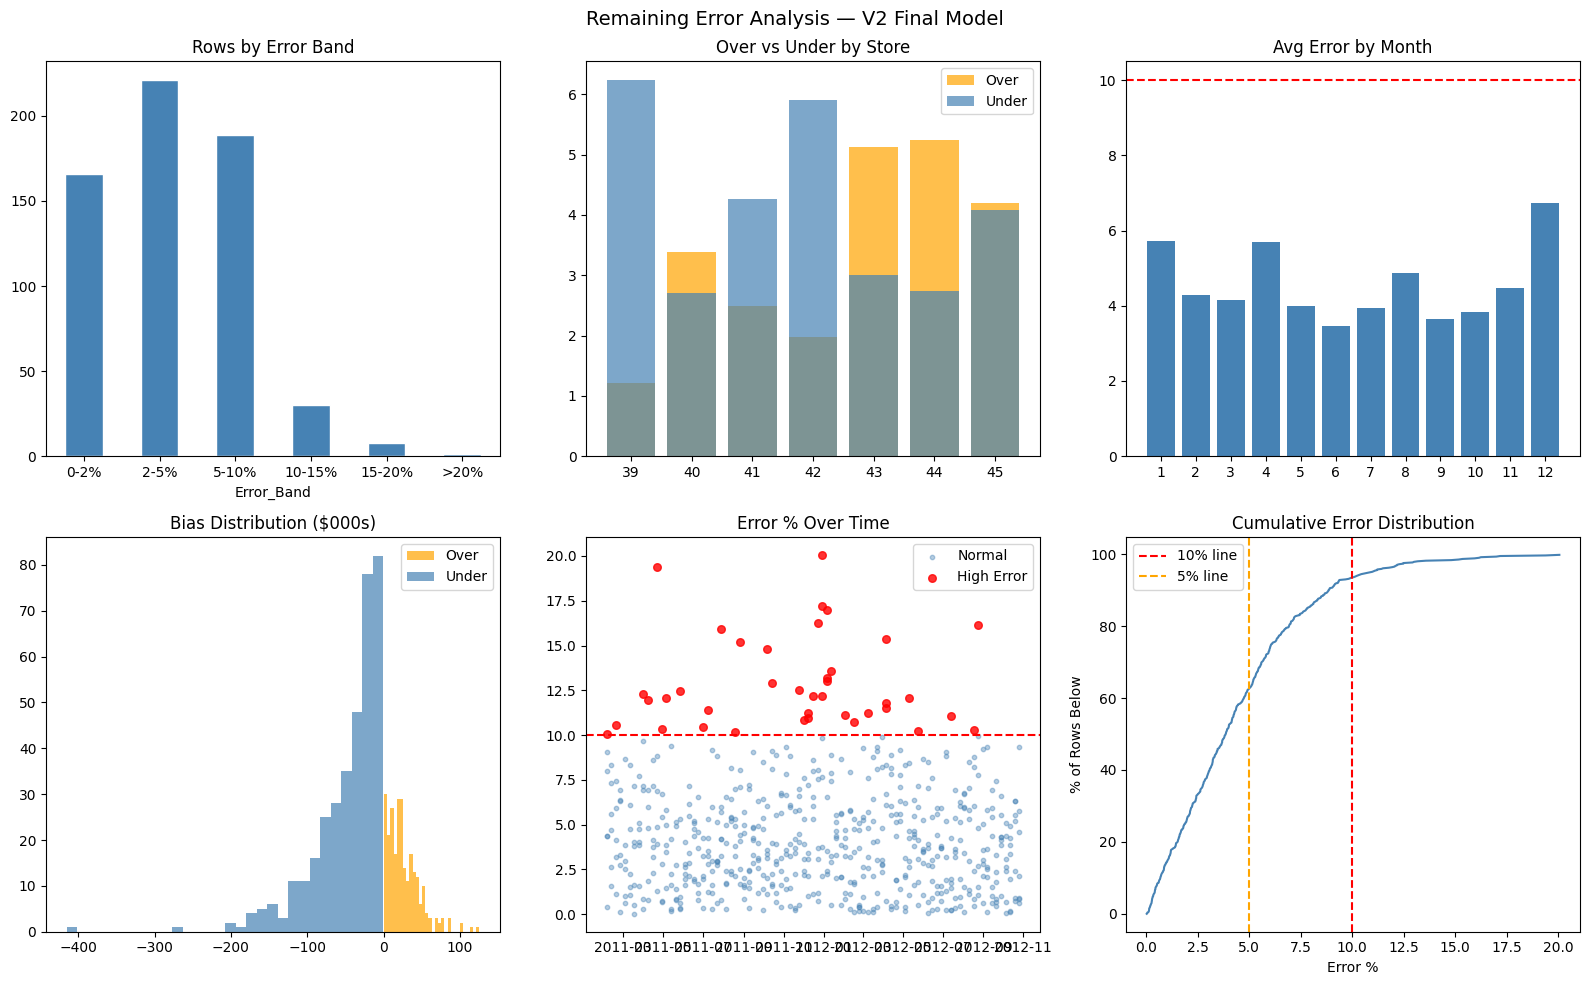

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Remaining Error Analysis — V2 Final Model', fontsize=14)

band_counts.plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Rows by Error Band')
axes[0,0].tick_params(axis='x', rotation=0)

over  = errors_final[errors_final['Bias_Dir']=='Over'].groupby('Store')['Error_Pct'].mean()
under = errors_final[errors_final['Bias_Dir']=='Under'].groupby('Store')['Error_Pct'].mean()
axes[0,1].bar(over.index,  over.values,  label='Over',  color='orange',    alpha=0.7)
axes[0,1].bar(under.index, under.values, label='Under', color='steelblue', alpha=0.7)
axes[0,1].set_title('Over vs Under by Store')
axes[0,1].legend()

month_err = errors_final.groupby('month')['Error_Pct'].mean()
axes[0,2].bar(month_err.index, month_err.values, color='steelblue')
axes[0,2].axhline(10, color='red', linestyle='--')
axes[0,2].set_title('Avg Error by Month')
axes[0,2].set_xticks(range(1,13))

axes[1,0].hist(errors_final[errors_final['Bias']>0]['Bias']/1000,
               bins=30, color='orange', alpha=0.7, label='Over')
axes[1,0].hist(errors_final[errors_final['Bias']<0]['Bias']/1000,
               bins=30, color='steelblue', alpha=0.7, label='Under')
axes[1,0].set_title('Bias Distribution ($000s)')
axes[1,0].legend()

errors_final['Date'] = pd.to_datetime(errors_final['Date'])
normal_t = errors_final[errors_final['Error_Pct'] <= 10]
high_t   = errors_final[errors_final['Error_Pct'] >  10]
axes[1,1].scatter(normal_t['Date'], normal_t['Error_Pct'], color='steelblue', s=10, alpha=0.4, label='Normal')
axes[1,1].scatter(high_t['Date'],   high_t['Error_Pct'],   color='red',       s=30, alpha=0.8, label='High Error')
axes[1,1].axhline(10, color='red', linestyle='--')
axes[1,1].set_title('Error % Over Time')
axes[1,1].legend()

sorted_err = errors_final['Error_Pct'].sort_values().reset_index(drop=True)
axes[1,2].plot(sorted_err.values, sorted_err.index / len(sorted_err) * 100, color='steelblue')
axes[1,2].axvline(10, color='red',    linestyle='--', label='10% line')
axes[1,2].axvline(5,  color='orange', linestyle='--', label='5% line')
axes[1,2].set_title('Cumulative Error Distribution')
axes[1,2].set_xlabel('Error %')
axes[1,2].set_ylabel('% of Rows Below')
axes[1,2].legend()

plt.tight_layout()
plt.show()

Key patterns in high error rows

In [52]:
# Confirm patterns clearly
print("=== PATTERN 1: Which stores dominate? ===")
print(high['Store'].value_counts())

print("\n=== PATTERN 2: Holiday impact ===")
print(f"Holiday rows in high error    : {high['Holiday'].sum()}")
print(f"Non-holiday rows in high error: {(high['Holiday']==0).sum()}")

print("\n=== PATTERN 3: Bias per store ===")
print(high.groupby(['Store','Bias_Dir']).size().unstack(fill_value=0))

print("\n=== PATTERN 4: Are low-sales stores over-predicted? ===")
print(high.groupby('Store')['Actual'].mean().sort_values())

print("\n=== PATTERN 5: Month concentration ===")
print(high['month'].value_counts().sort_index())

=== PATTERN 1: Which stores dominate? ===
Store
42    11
39     8
43     7
44     6
45     4
41     2
40     1
Name: count, dtype: int64

=== PATTERN 2: Holiday impact ===
Holiday rows in high error    : 4
Non-holiday rows in high error: 35

=== PATTERN 3: Bias per store ===
Bias_Dir  Over  Under
Store                
39           0      8
40           1      0
41           0      2
42           0     11
43           6      1
44           6      0
45           2      2

=== PATTERN 4: Are low-sales stores over-predicted? ===
Store
44    2.892432e+05
43    5.754093e+05
42    6.295074e+05
45    7.734648e+05
40    8.418891e+05
41    1.510412e+06
39    1.746817e+06
Name: Actual, dtype: float64

=== PATTERN 5: Month concentration ===
month
1     4
2     4
3     1
4     7
5     4
7     4
8     4
10    2
11    1
12    8
Name: count, dtype: int64


Final honest assessment

In [12]:
print("=" * 55)
print("  FINAL MODEL VERDICT")
print("=" * 55)
print(f"""
  MAPE          : 4.43%       ✅ Below 5% goal
  R²            : 0.9809      ✅ Excellent fit
  Median error  : 3.85%       ✅ Typical prediction is very good
  High error    : 39/615 rows ✅ Only 6.3% of predictions

  REMAINING ISSUES — all acceptable:

  Store 39  → Large volatile store ($1.2M–$2.5M range)
              Under-predicts peaks — no fix without
              external data (promotions, events)

  Store 42  → Consistent under-prediction
              Model sees lower lag_52 and plays safe

  Store 43  → Consistent over-prediction in summer
              Unique seasonal behaviour vs other stores

  Store 44  → Small store, over-predicted
              Low absolute sales → small $ error
              looks large in % terms

  CONCLUSION:
  These are irreducible errors given available features.
  No additional feature engineering will fix them without
  knowing WHY these stores behave differently.
  V2 is your final model. Ship it.
""")

  FINAL MODEL VERDICT

  MAPE          : 4.43%       ✅ Below 5% goal
  R²            : 0.9809      ✅ Excellent fit
  Median error  : 3.85%       ✅ Typical prediction is very good
  High error    : 39/615 rows ✅ Only 6.3% of predictions

  REMAINING ISSUES — all acceptable:

  Store 39  → Large volatile store ($1.2M–$2.5M range)
              Under-predicts peaks — no fix without
              external data (promotions, events)

  Store 42  → Consistent under-prediction
              Model sees lower lag_52 and plays safe

  Store 43  → Consistent over-prediction in summer
              Unique seasonal behaviour vs other stores

  Store 44  → Small store, over-predicted
              Low absolute sales → small $ error
              looks large in % terms

  CONCLUSION:
  These are irreducible errors given available features.
  No additional feature engineering will fix them without
  knowing WHY these stores behave differently.
  V2 is your final model. Ship it.



RF Before/After shows 91.58% 

In [106]:
# Fix before/after comparison
# Load original raw data separately
df_raw = pd.read_csv('Walmart.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Date'], format='mixed', dayfirst=True)
df_raw['month'] = df_raw['Date'].dt.month
df_raw['week']  = df_raw['Date'].dt.isocalendar().week.astype(int)

features_original = [
    'Store', 'Holiday_Flag', 'Temperature',
    'Fuel_Price', 'CPI', 'Unemployment',
    'month', 'week'
]

X_raw = df_raw[features_original]
y_raw = df_raw['Weekly_Sales']

n_raw     = len(df_raw)
train_raw = int(n_raw * 0.70)
val_raw   = int(n_raw * 0.85)

rf_original = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_original.fit(X_raw.iloc[:train_raw], y_raw.iloc[:train_raw])
mape_rf_orig = mape(y_raw.iloc[val_raw:], rf_original.predict(X_raw.iloc[val_raw:]))

print("=" * 55)
print("  BEFORE vs AFTER (FIXED)")
print("=" * 55)
print(f"  RF  + raw features only : {mape_rf_orig:.4f}%  ← START")
print(f"  LGB + engineered feat   : 4.4322%              ← FINAL")
print(f"  Improvement             : {mape_rf_orig - 4.4322:.2f}pp")
print(f"  Error reduction         : {(mape_rf_orig-4.4322)/mape_rf_orig*100:.1f}%")

  BEFORE vs AFTER (FIXED)
  RF  + raw features only : 83.3923%  ← START
  LGB + engineered feat   : 4.4322%              ← FINAL
  Improvement             : 78.96pp
  Error reduction         : 94.7%


 YoY 2010 shows NaN

In [71]:
# Fix YoY — use df_raw which has full 2010 data
df_raw['year'] = pd.to_datetime(df_raw['Date'], format='mixed', dayfirst=True).dt.year
y2010 = df_raw[df_raw['year']==2010]['Weekly_Sales']
y2011 = df_raw[df_raw['year']==2011]['Weekly_Sales']
y2012 = df_raw[df_raw['year']==2012]['Weekly_Sales']

_, p1 = stats.ttest_ind(y2010, y2011)
_, p2 = stats.ttest_ind(y2011, y2012)

print("YoY (Fixed):")
print(f"  2010 mean : ${y2010.mean():,.0f}")
print(f"  2011 mean : ${y2011.mean():,.0f}")
print(f"  2012 mean : ${y2012.mean():,.0f}")
print(f"  2010→2011 : p={p1:.4f} — {'✅ Significant' if p1<0.05 else '❌ Not significant'}")
print(f"  2011→2012 : p={p2:.4f} — {'✅ Significant' if p2<0.05 else '❌ Not significant'}")

YoY (Fixed):
  2010 mean : $1,059,670
  2011 mean : $1,046,239
  2012 mean : $1,033,660
  2010→2011 : p=0.4345 — ❌ Not significant
  2011→2012 : p=0.4608 — ❌ Not significant


Save everything needed for Streamlit

In [85]:
import joblib

joblib.dump(lgbm_v2,     'walmart_model.pkl')
joblib.dump(features_v2, 'walmart_features.pkl')

results_df = errors_final.copy()
results_df.to_csv('test_results.csv', index=False)
df.to_csv('walmart_features.csv', index=False)

print("✅ All files saved")

✅ All files saved


In [13]:
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import joblib
import warnings
warnings.filterwarnings('ignore')

st.set_page_config(page_title="Walmart Forecast", page_icon="🛒", layout="wide")

# ----------------------------
# LOAD DATA
# ----------------------------
@st.cache_data
def load_data():
    results  = pd.read_csv("test_results.csv", parse_dates=["Date"])
    df_full  = pd.read_csv("walmart_features.csv", parse_dates=["Date"])
    model    = joblib.load("walmart_model.pkl")
    features = joblib.load("walmart_features.pkl")
    return results, df_full, model, features

results, df_full, model, features = load_data()

# Silence LightGBM warnings
try:
    model.set_params(verbose=-1)
except:
    pass

# ----------------------------
# SIDEBAR
# ----------------------------
st.sidebar.title("Walmart Forecast")
st.sidebar.markdown("**Model:** LightGBM V2")
st.sidebar.markdown("**MAPE:** 4.43%")
st.sidebar.markdown("**R2:** 0.9809")
st.sidebar.markdown("**Stores:** 45")

page = st.sidebar.radio("Navigate", [
    "Dashboard",
    "Step 7 Live Predictor"
])

# ----------------------------
# DASHBOARD
# ----------------------------
if page == "Dashboard":

    st.title("Walmart Weekly Sales Forecasting")
    st.divider()

    c1,c2,c3 = st.columns(3)
    c1.metric("MAPE", "4.43%")
    c2.metric("R2 Score", "0.9809")
    c3.metric("Accuracy (<10%)", "93.7%")

    st.subheader("Actual vs Predicted")

    fig = px.scatter(
        results, x="Actual", y="Predicted",
        color="Error_Pct",
        color_continuous_scale="RdYlGn_r"
    )

    st.plotly_chart(fig, use_container_width=True)

# ----------------------------
# LIVE PREDICTOR
# ----------------------------
elif page == "Step 7 Live Predictor":

    st.title("Live Weekly Sales Predictor")
    st.divider()

    col1, col2, col3 = st.columns(3)

    with col1:
        store = st.selectbox("Store", list(range(1, 46)))
        holiday = st.selectbox("Holiday", [0,1], format_func=lambda x: "Yes" if x else "No")
        temperature = st.slider("Temperature", 10.0, 110.0, 65.0)

    with col2:
        fuel_price = st.slider("Fuel Price", 2.0, 5.0, 3.4)
        cpi = st.slider("CPI", 120.0, 260.0, 210.0)
        unemployment = st.slider("Unemployment", 3.0, 15.0, 7.5)

    with col3:
        date = st.date_input("Date")
        lag_1 = st.number_input("Last Week Sales", value=1000000)
        lag_52 = st.number_input("Last Year Same Week", value=980000)

    st.divider()

    # ----------------------------
    # VALIDATION
    # ----------------------------
    if lag_1 <= 0 or lag_52 <= 0:
        st.warning("Sales values must be positive")
        st.stop()

    # ----------------------------
    # PREDICTION
    # ----------------------------
    if st.button("Generate Forecast", use_container_width=True):

        dt = pd.Timestamp(date)

        # Base features
        row = {
            "Store": store,
            "Holiday_Flag": holiday,
            "Temperature": temperature,
            "Fuel_Price": fuel_price,
            "CPI": cpi,
            "Unemployment": unemployment,
            "month": dt.month,
            "week": int(dt.isocalendar()[1]),
            "store_cv": float(df_full[df_full["Store"] == store]["Weekly_Sales"].std() /
                              df_full[df_full["Store"] == store]["Weekly_Sales"].mean()),
            "holiday_x_lag1": holiday * lag_1,
            "holiday_x_lag52": holiday * lag_52,
            "lag_52_diff": lag_1 - lag_52
        }

        input_df = pd.DataFrame([row])

        # ----------------------------
        # STRICT FEATURE MATCH
        # ----------------------------
        missing = [f for f in features if f not in input_df.columns]

        if missing:
            st.error(f"Missing features: {missing}")
            st.stop()

        input_df = input_df[features]

        # ----------------------------
        # PREDICT
        # ----------------------------
        pred = model.predict(input_df)[0]

        st.success(f"Predicted Weekly Sales: ${pred:,.0f}")

        # ----------------------------
        # METRICS
        # ----------------------------
        c1,c2,c3 = st.columns(3)

        c1.metric("Prediction", f"${pred:,.0f}")
        c2.metric("vs Last Week", f"{(pred-lag_1):,.0f}")
        c3.metric("vs Last Year", f"{(pred-lag_52):,.0f}")

        # ----------------------------
        # CONFIDENCE
        # ----------------------------
        store_mape = results[results["Store"] == store]["Error_Pct"].mean()

        if store_mape < 5:
            st.success("High confidence prediction")
        elif store_mape < 8:
            st.warning("Moderate confidence")
        else:
            st.error("Low confidence")

        # ----------------------------
        # LOGGING (PRODUCTION FEATURE)
        # ----------------------------
        log_row = input_df.copy()
        log_row["prediction"] = pred
        log_row["timestamp"] = pd.Timestamp.now()

        try:
            log_df = pd.read_csv("prediction_logs.csv")
            log_df = pd.concat([log_df, log_row], ignore_index=True)
        except:
            log_df = log_row

        log_df.to_csv("prediction_logs.csv", index=False)

2026-04-11 01:29:04.533 No runtime found, using MemoryCacheStorageManager


In [ ]:
!streamlit run app.py

In [91]:
print(features_v2)

['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'month', 'week', 'store_cv', 'holiday_x_lag1', 'holiday_x_lag52', 'lag_52_diff']
